# Import statements

In [2]:
import pickle
import numpy as np
import pandas as pd

In [3]:
import skopt
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import tqdm as notebook_tqdm

In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

In [5]:
from skopt import BayesSearchCV
from sklearn.svm import SVR
from skopt.space import Real, Categorical, Integer

In [6]:
import xgboost as xgb

from math import sqrt

In [7]:
import shap

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import plot_importance
from matplotlib import pyplot

In [9]:
from platform import python_version

print(python_version())



3.10.12


In [10]:
print(np.__version__)

1.26.3


# Preprocessing datasets 

## Phenotype dataset

In [26]:
#Load file
phenotype = pd.read_csv("../phenotype/bbd.txt", sep='\t')

In [27]:
phenotype.head()

,Unnamed: 0,Line,LL,LW,PLH,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,0,s63,7.96667,5.90000,24.0667,2.00000,s63_BeiJing_2013,1,0,0,0,0,0,1,35
1,1,s64,8.56667,5.00000,27.0333,4.66667,s64_BeiJing_2013,1,0,0,0,0,0,1,35
2,2,s66,6.40000,4.53333,101.2670,4.00000,s66_BeiJing_2013,1,0,0,0,0,0,1,53
3,3,s70,10.40000,8.23333,76.3667,6.66667,s70_BeiJing_2013,1,0,0,0,0,0,1,69
4,4,s71,9.13333,6.93333,98.8000,5.66667,s71_BeiJing_2013,1,0,0,0,0,0,1,53


In [28]:
phenotype= phenotype.drop(['Unnamed: 0'], axis=1)

In [29]:
phenotype.head()

,Line,LL,LW,PLH,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s63,7.96667,5.90000,24.0667,2.00000,s63_BeiJing_2013,1,0,0,0,0,0,1,35
1,s64,8.56667,5.00000,27.0333,4.66667,s64_BeiJing_2013,1,0,0,0,0,0,1,35
2,s66,6.40000,4.53333,101.2670,4.00000,s66_BeiJing_2013,1,0,0,0,0,0,1,53
3,s70,10.40000,8.23333,76.3667,6.66667,s70_BeiJing_2013,1,0,0,0,0,0,1,69
4,s71,9.13333,6.93333,98.8000,5.66667,s71_BeiJing_2013,1,0,0,0,0,0,1,53


In [30]:
phenotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3170 entries, 0 to 3169
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Line               3170 non-null   object 
 1   LL                 3170 non-null   float64
 2   LW                 3170 non-null   float64
 3   PLH                3170 non-null   float64
 4   VBN                3170 non-null   float64
 5   new_line           3170 non-null   object 
 6   BeiJing_2013       3170 non-null   int64  
 7   HeNan_2014         3170 non-null   int64  
 8   HeNan_2015         3170 non-null   int64  
 9   HeiLongJiang_2014  3170 non-null   int64  
 10  HeiLongJiang_2015  3170 non-null   int64  
 11  improved_cultivar  3170 non-null   int64  
 12  landrace           3170 non-null   int64  
 13  BBD                3170 non-null   int64  
dtypes: float64(4), int64(8), object(2)
memory usage: 346.8+ KB


## PCA dataset

In [33]:
#Load file
genotype = pd.read_csv('../pca_bbd/pca_bbd_raw.txt', sep=' ', header=None)

In [34]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,s63,-0.034901,0.036154,0.000695,-0.010007,-0.000814,0.018579,0.009525,-0.012036,-0.020408,...,-0.027510,-0.008367,0.024148,0.022595,-0.004854,0.007766,-0.021842,0.007906,-0.040497,0.003999
1,s64,0.012630,-0.015253,0.008432,0.044533,-0.064294,0.063312,0.017981,-0.014156,-0.040835,...,0.018936,-0.016615,-0.026148,0.028937,0.035152,0.029805,0.002569,0.033567,-0.023213,-0.029353
2,s66,-0.063739,0.047927,-0.008013,0.021293,0.022458,0.004759,0.000706,-0.007053,0.023448,...,0.026228,0.002728,0.068923,-0.024134,0.080053,-0.029368,0.007677,0.037396,-0.047216,-0.026159
3,s70,-0.069693,0.053746,-0.013704,0.000959,0.017226,-0.017455,0.024331,0.011214,0.002853,...,0.036510,-0.028901,0.020784,0.038372,-0.029239,0.011208,0.044544,0.004507,-0.013926,-0.002127
4,s71,-0.001140,0.034095,-0.034785,0.012238,-0.002233,0.033952,-0.036617,0.066924,-0.033514,...,0.012308,-0.016131,-0.025863,-0.021064,-0.002839,-0.007544,0.019314,0.002030,-0.005925,-0.013229


In [35]:
#Setting the index and naming the index column 

genotype = genotype.rename(columns={genotype.columns[0]: 'Line'})


In [36]:
genotype = genotype.reset_index().set_index('Line')
genotype.head()

,index,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s63,0,-0.034901,0.036154,0.000695,-0.010007,-0.000814,0.018579,0.009525,-0.012036,-0.020408,...,-0.027510,-0.008367,0.024148,0.022595,-0.004854,0.007766,-0.021842,0.007906,-0.040497,0.003999
s64,1,0.012630,-0.015253,0.008432,0.044533,-0.064294,0.063312,0.017981,-0.014156,-0.040835,...,0.018936,-0.016615,-0.026148,0.028937,0.035152,0.029805,0.002569,0.033567,-0.023213,-0.029353
s66,2,-0.063739,0.047927,-0.008013,0.021293,0.022458,0.004759,0.000706,-0.007053,0.023448,...,0.026228,0.002728,0.068923,-0.024134,0.080053,-0.029368,0.007677,0.037396,-0.047216,-0.026159
s70,3,-0.069693,0.053746,-0.013704,0.000959,0.017226,-0.017455,0.024331,0.011214,0.002853,...,0.036510,-0.028901,0.020784,0.038372,-0.029239,0.011208,0.044544,0.004507,-0.013926,-0.002127
s71,4,-0.001140,0.034095,-0.034785,0.012238,-0.002233,0.033952,-0.036617,0.066924,-0.033514,...,0.012308,-0.016131,-0.025863,-0.021064,-0.002839,-0.007544,0.019314,0.002030,-0.005925,-0.013229


In [37]:
genotype= genotype.drop(['index'], axis=1)

In [38]:
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s63,-0.034901,0.036154,0.000695,-0.010007,-0.000814,0.018579,0.009525,-0.012036,-0.020408,0.017118,...,-0.027510,-0.008367,0.024148,0.022595,-0.004854,0.007766,-0.021842,0.007906,-0.040497,0.003999
s64,0.012630,-0.015253,0.008432,0.044533,-0.064294,0.063312,0.017981,-0.014156,-0.040835,0.004999,...,0.018936,-0.016615,-0.026148,0.028937,0.035152,0.029805,0.002569,0.033567,-0.023213,-0.029353
s66,-0.063739,0.047927,-0.008013,0.021293,0.022458,0.004759,0.000706,-0.007053,0.023448,0.021674,...,0.026228,0.002728,0.068923,-0.024134,0.080053,-0.029368,0.007677,0.037396,-0.047216,-0.026159
s70,-0.069693,0.053746,-0.013704,0.000959,0.017226,-0.017455,0.024331,0.011214,0.002853,-0.026395,...,0.036510,-0.028901,0.020784,0.038372,-0.029239,0.011208,0.044544,0.004507,-0.013926,-0.002127
s71,-0.001140,0.034095,-0.034785,0.012238,-0.002233,0.033952,-0.036617,0.066924,-0.033514,0.002867,...,0.012308,-0.016131,-0.025863,-0.021064,-0.002839,-0.007544,0.019314,0.002030,-0.005925,-0.013229


In [39]:
pca_data = pd.merge(genotype, phenotype, on='Line', how='outer', indicator=False)

In [40]:
pca_data.head()

,Line,1,2,3,4,5,6,7,8,9,...,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,5.66667,s100_BeiJing_2013,1,0,0,0,0,0,1,61
1,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,1.80000,s100_HeNan_2014,0,1,0,0,0,0,1,37
2,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,3.40000,s100_HeNan_2015,0,0,1,0,0,0,1,43
3,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,6.33333,s101_BeiJing_2013,1,0,0,0,0,0,1,39
4,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,4.20000,s101_HeiLongJiang_2014,0,0,0,1,0,0,1,62


In [41]:
pca_data = pca_data.reset_index().set_index('Line')
pca_data= pca_data.drop(['index'], axis=1)
pca_data.head()

,1,2,3,4,5,6,7,8,9,10,...,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,0.010999,...,5.66667,s100_BeiJing_2013,1,0,0,0,0,0,1,61
s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,0.010999,...,1.80000,s100_HeNan_2014,0,1,0,0,0,0,1,37
s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,0.010999,...,3.40000,s100_HeNan_2015,0,0,1,0,0,0,1,43
s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,-0.005544,...,6.33333,s101_BeiJing_2013,1,0,0,0,0,0,1,39
s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,-0.005544,...,4.20000,s101_HeiLongJiang_2014,0,0,0,1,0,0,1,62


In [42]:
pca_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3170 entries, s100 to s99
Columns: 513 entries, 1 to BBD
dtypes: float64(504), int64(8), object(1)
memory usage: 12.4+ MB


In [17]:
#pca_data.to_pickle("full_bbd_filtered_pca_data.pkl")
#Load file
pca_data_bbd = pd.read_pickle("full_bbd_filtered_pca_data.pkl")

In [18]:
pca_data_md = pd.read_pickle("full_md_filtered_pca_data.pkl")

In [19]:
pca_data_prt = pd.read_pickle("full_prt_filtered_pca_data.pkl")

In [27]:
pca_data_bbd= pca_data_bbd.reset_index().set_index('new_line')
pca_data_bbd.head()

,Line,1,2,3,4,5,6,7,8,9,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,154.7000,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,130.0000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,116.0000,3.40000,0,0,1,0,0,0,1,43
s101_BeiJing_2013,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,95.7000,4.20000,0,0,0,1,0,0,1,62


In [29]:
pca_data_md= pca_data_md.reset_index().set_index('new_line')
pca_data_md.head()

,Line,1,2,3,4,5,6,7,8,9,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,154.7000,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2014,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s100_HeNan_2015,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,116.0000,3.40000,0,0,1,0,0,0,1,115.0
s101_BeiJing_2013,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2014,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,95.7000,4.20000,0,0,0,1,0,0,1,149.0


In [30]:
pca_data_prt= pca_data_prt.reset_index().set_index('new_line')
pca_data_prt.head()

,Line,1,2,3,4,5,6,7,8,9,...,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.056954,61.0,9.50000,6.26667,154.7000,6.784,1,0,0,340.553
s100_HeNan_2014,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.056954,37.0,10.22000,7.19333,130.0000,7.126,0,1,0,358.104
s101_BeiJing_2013,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,-0.010386,39.0,8.93333,6.53333,52.7333,8.786,1,0,0,355.712
s101_HeiLongJiang_2014,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,-0.010386,62.0,14.28000,10.22000,95.7000,7.624,0,0,1,385.915
s1014_BeiJing_2013,s1014,0.096765,0.028196,-0.002583,0.022170,-0.025105,-0.001168,-0.016909,-0.089279,0.030493,...,0.000719,77.0,10.36670,7.76667,111.7330,7.474,1,0,0,366.116


In [31]:
pca_data_bbd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3170 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 513 entries, Line to BBD
dtypes: float64(504), int64(8), object(1)
memory usage: 12.4+ MB


In [32]:
pca_data_md.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3063 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 513 entries, Line to MD
dtypes: float64(505), int64(7), object(1)
memory usage: 12.0+ MB


In [33]:
pca_data_prt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1334 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2014
Columns: 510 entries, Line to PRT
dtypes: float64(506), int64(3), object(1)
memory usage: 5.2+ MB


In [34]:
pca_bbd = pca_data_bbd.iloc[:, 0:512]
pca_bbd.head()

,Line,1,2,3,4,5,6,7,8,9,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,6.26667,154.7000,5.66667,1,0,0,0,0,0,1
s100_HeNan_2014,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s100_HeNan_2015,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,4.00000,116.0000,3.40000,0,0,1,0,0,0,1
s101_BeiJing_2013,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101_HeiLongJiang_2014,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1


In [35]:
pca_md = pca_data_md.iloc[:, 0:512]
pca_md.head()

,Line,1,2,3,4,5,6,7,8,9,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,6.26667,154.7000,5.66667,1,0,0,0,0,0,1
s100_HeNan_2014,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s100_HeNan_2015,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,4.00000,116.0000,3.40000,0,0,1,0,0,0,1
s101_BeiJing_2013,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101_HeiLongJiang_2014,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1


In [36]:
pca_prt = pca_data_prt.iloc[:, 0:509]
pca_prt.head()

,Line,1,2,3,4,5,6,7,8,9,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.001952,-0.056954,61.0,9.50000,6.26667,154.7000,6.784,1,0,0
s100_HeNan_2014,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.001952,-0.056954,37.0,10.22000,7.19333,130.0000,7.126,0,1,0
s101_BeiJing_2013,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,0.014513,-0.010386,39.0,8.93333,6.53333,52.7333,8.786,1,0,0
s101_HeiLongJiang_2014,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,0.014513,-0.010386,62.0,14.28000,10.22000,95.7000,7.624,0,0,1
s1014_BeiJing_2013,s1014,0.096765,0.028196,-0.002583,0.022170,-0.025105,-0.001168,-0.016909,-0.089279,0.030493,...,-0.001958,0.000719,77.0,10.36670,7.76667,111.7330,7.474,1,0,0


In [37]:
bbd= pca_data_bbd.iloc[:, 512:]
bbd.head()

,BBD
new_line,
s100_BeiJing_2013,61
s100_HeNan_2014,37
s100_HeNan_2015,43
s101_BeiJing_2013,39
s101_HeiLongJiang_2014,62


In [38]:
md= pca_data_md.iloc[:, 512:]
md.head()

,MD
new_line,
s100_BeiJing_2013,155.0
s100_HeNan_2014,117.0
s100_HeNan_2015,115.0
s101_BeiJing_2013,121.0
s101_HeiLongJiang_2014,149.0


In [39]:
prt= pca_data_prt.iloc[:, 509:]
prt.head()

,PRT
new_line,
s100_BeiJing_2013,340.553
s100_HeNan_2014,358.104
s101_BeiJing_2013,355.712
s101_HeiLongJiang_2014,385.915
s1014_BeiJing_2013,366.116


## Split for training and holdout

In [40]:
X_train_b, X_holdout_b, y_train_b, y_holdout_b = train_test_split(pca_bbd, bbd, test_size=0.2, random_state=42)

In [41]:
X_train_m, X_holdout_m, y_train_m, y_holdout_m = train_test_split(pca_md, md, test_size=0.2, random_state=42)

In [42]:
X_train_p, X_holdout_p, y_train_p, y_holdout_p = train_test_split(pca_prt, prt, test_size=0.2, random_state=42)

In [54]:
X_train_p.head()

,Line,1,2,3,4,5,6,7,8,9,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
new_line,,,,,,,,,,,,,,,,,,,,,
s844_BeiJing_2013,s844,0.047723,0.006524,-0.007488,0.022130,-0.014157,0.003341,0.079441,-0.013310,0.042492,...,0.038248,0.004386,59.0,10.23330,7.20000,96.00,7.434,1,0,0
s754_HeiLongJiang_2014,s754,-0.019630,0.022483,-0.007358,-0.013178,0.029880,0.025408,0.003410,0.067198,0.021993,...,0.020752,-0.013267,60.0,15.69330,6.41333,66.32,5.990,0,0,1
s662_HeNan_2014,s662,-0.031979,-0.018534,0.064240,0.003042,0.009271,-0.002359,0.052673,-0.076434,-0.009891,...,-0.027761,0.072563,35.0,9.68667,6.59333,77.00,8.134,0,1,0
s449_BeiJing_2013,s449,-0.002737,0.018978,0.004156,-0.035264,0.051835,-0.043596,0.072704,0.073643,0.001918,...,0.070609,0.034234,41.0,9.20000,6.73333,73.80,7.118,1,0,0
s190_HeiLongJiang_2014,s190,0.028965,0.021948,-0.002958,-0.015534,0.015381,-0.020044,0.030427,0.068150,-0.028853,...,0.006555,-0.018785,60.0,13.10000,8.60667,49.94,7.330,0,0,1


In [55]:
X_train_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067 entries, s844_BeiJing_2013 to s762_HeiLongJiang_2014
Columns: 509 entries, Line to HeiLongJiang_2014
dtypes: float64(505), int64(3), object(1)
memory usage: 4.2+ MB


In [56]:
X_holdout_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 267 entries, s625_BeiJing_2013 to s739_BeiJing_2013
Columns: 509 entries, Line to HeiLongJiang_2014
dtypes: float64(505), int64(3), object(1)
memory usage: 1.0+ MB


In [57]:
y_train_p.head()

,PRT
new_line,
s844_BeiJing_2013,367.541
s754_HeiLongJiang_2014,315.181
s662_HeNan_2014,337.968
s449_BeiJing_2013,388.594
s190_HeiLongJiang_2014,368.171


In [48]:
X_train_b.to_pickle("x_train_pca_bbd.pkl")
y_train_b.to_pickle("y_train_pca_bbd.pkl")
X_holdout_b.to_pickle("x_holdout_pca_bbd.pkl")
y_holdout_b.to_pickle("y_holdout_pca_bbd.pkl")

In [53]:
X_train_m.to_pickle("x_train_pca_md.pkl")
y_train_m.to_pickle("y_train_pca_md.pkl")
X_holdout_m.to_pickle("x_holdout_pca_md.pkl")
y_holdout_m.to_pickle("y_holdout_pca_md.pkl")

In [58]:
X_train_p.to_pickle("x_train_pca_prt.pkl")
y_train_p.to_pickle("y_train_pca_prt.pkl")
X_holdout_p.to_pickle("x_holdout_pca_prt.pkl")
y_holdout_p.to_pickle("y_holdout_pca_prt.pkl")

In [78]:
X_train_b = X_train_b.reset_index()
#X_train_b= X_train_b.drop(['index'], axis=1)
X_train_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s2095_HeiLongJiang_2014,s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
1,s678_HeNan_2014,s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
2,s204_HeNan_2015,s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
3,s640_HeNan_2015,s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
4,s655_HeNan_2014,s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [77]:
X_train_m = X_train_m.reset_index()
X_train_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s503_BeiJing_2013,s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
1,s2833_HeNan_2015,s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
2,s1616_HeNan_2015,s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
3,s833_HeNan_2014,s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
4,s265_HeNan_2014,s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [79]:
X_train_p = X_train_p.reset_index()
X_train_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
0,s844_BeiJing_2013,s844,0.047723,0.006524,-0.007488,0.022130,-0.014157,0.003341,0.079441,-0.013310,...,0.038248,0.004386,59.0,10.23330,7.20000,96.00,7.434,1,0,0
1,s754_HeiLongJiang_2014,s754,-0.019630,0.022483,-0.007358,-0.013178,0.029880,0.025408,0.003410,0.067198,...,0.020752,-0.013267,60.0,15.69330,6.41333,66.32,5.990,0,0,1
2,s662_HeNan_2014,s662,-0.031979,-0.018534,0.064240,0.003042,0.009271,-0.002359,0.052673,-0.076434,...,-0.027761,0.072563,35.0,9.68667,6.59333,77.00,8.134,0,1,0
3,s449_BeiJing_2013,s449,-0.002737,0.018978,0.004156,-0.035264,0.051835,-0.043596,0.072704,0.073643,...,0.070609,0.034234,41.0,9.20000,6.73333,73.80,7.118,1,0,0
4,s190_HeiLongJiang_2014,s190,0.028965,0.021948,-0.002958,-0.015534,0.015381,-0.020044,0.030427,0.068150,...,0.006555,-0.018785,60.0,13.10000,8.60667,49.94,7.330,0,0,1


In [80]:
pca_full_train_b = pd.merge(X_train_b, y_train_b, on='new_line', how='right', indicator=False)
pca_full_train_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s2095_HeiLongJiang_2014,s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,...,54.12,4.0,0,0,0,1,0,1,0,59
1,s678_HeNan_2014,s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,...,66.00,1.6,0,1,0,0,0,1,0,41
2,s204_HeNan_2015,s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,...,49.00,3.0,0,0,1,0,0,1,0,43
3,s640_HeNan_2015,s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,...,90.00,0.0,0,0,1,0,0,1,0,42
4,s655_HeNan_2014,s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,...,70.00,1.8,0,1,0,0,0,1,0,30


In [81]:
pca_full_train_m = pd.merge(X_train_m, y_train_m, on='new_line', how='right', indicator=False)
pca_full_train_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
0,s503_BeiJing_2013,s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,...,43.9333,5.33333,1,0,0,0,0,0,1,113.0
1,s2833_HeNan_2015,s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,...,83.2000,1.40000,0,0,1,0,0,1,0,107.0
2,s1616_HeNan_2015,s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,...,60.8000,3.80000,0,0,1,0,0,1,0,100.0
3,s833_HeNan_2014,s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,...,67.0000,0.80000,0,1,0,0,0,1,0,103.0
4,s265_HeNan_2014,s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,...,79.0000,1.00000,0,1,0,0,0,1,0,103.0


In [82]:
pca_full_train_p = pd.merge(X_train_p, y_train_p, on='new_line', how='right', indicator=False)
pca_full_train_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,PRT
0,s844_BeiJing_2013,s844,0.047723,0.006524,-0.007488,0.022130,-0.014157,0.003341,0.079441,-0.013310,...,0.004386,59.0,10.23330,7.20000,96.00,7.434,1,0,0,367.541
1,s754_HeiLongJiang_2014,s754,-0.019630,0.022483,-0.007358,-0.013178,0.029880,0.025408,0.003410,0.067198,...,-0.013267,60.0,15.69330,6.41333,66.32,5.990,0,0,1,315.181
2,s662_HeNan_2014,s662,-0.031979,-0.018534,0.064240,0.003042,0.009271,-0.002359,0.052673,-0.076434,...,0.072563,35.0,9.68667,6.59333,77.00,8.134,0,1,0,337.968
3,s449_BeiJing_2013,s449,-0.002737,0.018978,0.004156,-0.035264,0.051835,-0.043596,0.072704,0.073643,...,0.034234,41.0,9.20000,6.73333,73.80,7.118,1,0,0,388.594
4,s190_HeiLongJiang_2014,s190,0.028965,0.021948,-0.002958,-0.015534,0.015381,-0.020044,0.030427,0.068150,...,-0.018785,60.0,13.10000,8.60667,49.94,7.330,0,0,1,368.171


In [83]:
pca_full_train_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2536 entries, 0 to 2535
Columns: 514 entries, new_line to BBD
dtypes: float64(504), int64(8), object(2)
memory usage: 9.9+ MB


In [84]:
pca_full_train_m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Columns: 514 entries, new_line to MD
dtypes: float64(505), int64(7), object(2)
memory usage: 9.6+ MB


In [85]:
pca_full_train_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Columns: 511 entries, new_line to PRT
dtypes: float64(506), int64(3), object(2)
memory usage: 4.2+ MB


In [86]:
pca_full_train_b.to_pickle("pca_full_training_bbd.pkl")
pca_full_train_m.to_pickle("pca_full_training_md.pkl")
pca_full_train_p.to_pickle("pca_full_training_prt.pkl")

In [90]:
X_holdout_b = X_holdout_b.reset_index()
#X_holdout_b= X_holdout_b.drop(['index'], axis=1)
X_holdout_b.head()


,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s143_HeNan_2014,s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
1,s525_HeNan_2015,s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
2,s2272_HeNan_2014,s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
3,s2255_HeiLongJiang_2014,s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
4,s1588_HeNan_2014,s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [88]:
X_holdout_m = X_holdout_m.reset_index()
X_holdout_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s2692_HeiLongJiang_2015,s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
1,s131_HeNan_2015,s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
2,s272_HeNan_2014,s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
3,s344_HeNan_2014,s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
4,s324_BeiJing_2013,s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [92]:
X_holdout_p = X_holdout_p.reset_index()
#X_holdout_p= X_holdout_p.drop(['index'], axis=1)
X_holdout_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
0,s625_BeiJing_2013,s625,-0.026468,0.002218,0.047288,0.021343,-0.070158,0.012411,-0.018335,0.071603,...,0.013756,-0.015567,61.0,8.7000,6.66667,67.5000,7.412,1,0,0
1,s722_BeiJing_2013,s722,-0.045996,0.024846,-0.055552,0.007956,0.019921,-0.040272,0.024809,-0.021013,...,-0.031883,0.056175,33.0,10.6000,4.33333,57.0333,7.206,1,0,0
2,s828_BeiJing_2013,s828,-0.003471,0.018158,-0.006217,-0.008056,0.055950,-0.066355,0.037500,-0.004974,...,-0.050015,0.018971,38.0,8.1000,6.36667,77.4667,7.272,1,0,0
3,s271_HeNan_2014,s271,-0.023611,0.055950,0.079366,-0.009974,-0.025017,0.045787,-0.001240,-0.040877,...,-0.052619,0.036257,30.0,9.4600,7.19333,87.0000,7.306,0,1,0
4,s231_HeNan_2014,s231,-0.013267,-0.069702,0.062598,0.020831,0.000861,0.032627,0.012150,0.019918,...,-0.003534,0.001959,50.0,12.3733,7.91333,120.0000,7.624,0,1,0


In [93]:
pca_full_holdout_b = pd.merge(X_holdout_b, y_holdout_b, on='new_line', how='right', indicator=False)
pca_full_holdout_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s143_HeNan_2014,s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,...,90.0,1.00000,0,1,0,0,0,0,1,42
1,s525_HeNan_2015,s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,...,200.4,1.40000,0,0,1,0,0,0,1,42
2,s2272_HeNan_2014,s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,...,46.6,0.80000,0,1,0,0,0,1,0,32
3,s2255_HeiLongJiang_2014,s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,...,49.8,4.66667,0,0,0,1,0,1,0,56
4,s1588_HeNan_2014,s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [94]:
pca_full_holdout_m = pd.merge(X_holdout_m, y_holdout_m, on='new_line', how='right', indicator=False)
pca_full_holdout_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
0,s2692_HeiLongJiang_2015,s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
1,s131_HeNan_2015,s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
2,s272_HeNan_2014,s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
3,s344_HeNan_2014,s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
4,s324_BeiJing_2013,s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [95]:
pca_full_holdout_p = pd.merge(X_holdout_p, y_holdout_p, on='new_line', how='right', indicator=False)
pca_full_holdout_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,PRT
0,s625_BeiJing_2013,s625,-0.026468,0.002218,0.047288,0.021343,-0.070158,0.012411,-0.018335,0.071603,...,-0.015567,61.0,8.7000,6.66667,67.5000,7.412,1,0,0,336.057
1,s722_BeiJing_2013,s722,-0.045996,0.024846,-0.055552,0.007956,0.019921,-0.040272,0.024809,-0.021013,...,0.056175,33.0,10.6000,4.33333,57.0333,7.206,1,0,0,360.402
2,s828_BeiJing_2013,s828,-0.003471,0.018158,-0.006217,-0.008056,0.055950,-0.066355,0.037500,-0.004974,...,0.018971,38.0,8.1000,6.36667,77.4667,7.272,1,0,0,386.365
3,s271_HeNan_2014,s271,-0.023611,0.055950,0.079366,-0.009974,-0.025017,0.045787,-0.001240,-0.040877,...,0.036257,30.0,9.4600,7.19333,87.0000,7.306,0,1,0,358.938
4,s231_HeNan_2014,s231,-0.013267,-0.069702,0.062598,0.020831,0.000861,0.032627,0.012150,0.019918,...,0.001959,50.0,12.3733,7.91333,120.0000,7.624,0,1,0,324.506


In [96]:
pca_full_holdout_b.to_pickle("pca_full_holdout_bbd.pkl")
pca_full_holdout_m.to_pickle("pca_full_holdout_md.pkl")
pca_full_holdout_p.to_pickle("pca_full_holdout_prt.pkl")

# All functions

In [8]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}
  

In [9]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [13]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [14]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)


In [15]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [1]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [17]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Protein Content (PRT) models

## Load and process dataset

In [136]:
pca_full_train_p = pd.read_pickle("../pickle_files/pca_full_training_prt.pkl")

In [137]:
pca_full_train_p = pca_full_train_p.reset_index().set_index('Line')
pca_full_train_p = pca_full_train_p.drop(['index','new_line'], axis=1)
pca_full_train_p.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,33,6.88000,9.02667,41.0000,0,1,0,1,0,328.773
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,61,7.20000,9.20000,62.5667,1,0,0,1,0,354.750
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,81,6.86667,9.60000,100.8670,1,0,0,1,0,332.734
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,77,8.00000,9.13333,98.3333,1,0,0,1,0,327.574
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,38,4.82000,9.82000,42.0000,0,1,0,1,0,376.204


In [138]:
pca_full_holdout_p = pd.read_pickle("../pickle_files/pca_full_holdout_prt.pkl")

In [139]:
pca_full_holdout_p = pca_full_holdout_p.reset_index().set_index('Line')
pca_full_holdout_p = pca_full_holdout_p.drop(['index','new_line'], axis=1)
pca_full_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,61,6.83333,9.73333,109.567,1,0,0,1,0,405.602
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,78,3.74000,9.98000,59.000,0,0,1,1,0,307.984
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,30,6.86667,9.42667,77.000,0,1,0,1,0,339.283
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,42,8.03333,10.66000,100.000,0,1,0,1,0,370.721
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,47,8.00000,10.36670,59.400,1,0,0,1,0,337.116


## PC200 Models

In [140]:
X = pd.concat([pca_full_train_p.iloc[:, :200], pca_full_train_p.iloc[:, -10:]], axis=1)
X = X.drop(['PRT'], axis=1)
X.head()

,1,2,3,4,5,6,7,8,9,10,...,200,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.004255,33,6.88000,9.02667,41.0000,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.007213,61,7.20000,9.20000,62.5667,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.021563,81,6.86667,9.60000,100.8670,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.031854,77,8.00000,9.13333,98.3333,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,0.009567,38,4.82000,9.82000,42.0000,0,1,0,1,0


In [141]:
X_dupe = pd.concat([pca_full_train_p.iloc[:, :200], pca_full_train_p.iloc[:, -10:]], axis=1)
X_dupe = X_dupe.drop(['PRT'], axis=1)
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,200,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.004255,33,6.88000,9.02667,41.0000,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.007213,61,7.20000,9.20000,62.5667,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.021563,81,6.86667,9.60000,100.8670,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.031854,77,8.00000,9.13333,98.3333,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,0.009567,38,4.82000,9.82000,42.0000,0,1,0,1,0


In [142]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s233 to s744
Columns: 209 entries, 1 to landrace
dtypes: float64(203), int64(6)
memory usage: 1.8+ MB


In [143]:
y = pca_full_train_p.iloc[:, 509:]
y.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [144]:
pca_loc= X.drop(['BBD', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,196,197,198,199,200,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,0.023067,-0.009843,0.023802,-0.018460,0.009567,0,1,0,1,0


In [145]:
pca_loc_dupe = X.drop(['BBD', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,196,197,198,199,200,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,0.023067,-0.009843,0.023802,-0.018460,0.009567,0,1,0,1,0


In [146]:
only_pca= pd.concat([pca_full_train_p.iloc[:, :200], pca_full_train_p.iloc[:, -3:]], axis=1)
only_pca= only_pca.drop(['PRT'], axis=1)
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.014839,0.013609,0.008501,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.014234,-0.019987,-0.006039,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.015354,0.037879,0.085191,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012463,0.065665,0.073180,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.016131,0.034417,-0.018315,0.023067,-0.009843,0.023802,-0.018460,0.009567,1,0


In [147]:
only_pca.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s233 to s744
Columns: 202 entries, 1 to landrace
dtypes: float64(200), int64(2)
memory usage: 1.7+ MB


In [148]:
only_pca_dupe = pd.concat([pca_full_train_p.iloc[:, :200], pca_full_train_p.iloc[:, -3:]], axis=1)
only_pca_dupe = only_pca_dupe .drop(['PRT'], axis=1)
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.014839,0.013609,0.008501,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.014234,-0.019987,-0.006039,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.015354,0.037879,0.085191,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012463,0.065665,0.073180,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.016131,0.034417,-0.018315,0.023067,-0.009843,0.023802,-0.018460,0.009567,1,0


### Models

### All features training

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [37]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,200,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s776,-0.017530,-0.032333,0.054655,-0.001789,-0.011154,-0.027620,-0.011509,-0.016235,-0.009594,-0.071494,...,0.001320,33,7.00667,10.42670,53.0000,0,1,0,1,0
s1641,-0.013956,-0.061772,0.009886,0.057141,0.022730,0.025527,0.023882,0.009194,0.028309,-0.004532,...,0.042861,64,8.90000,10.60000,137.6670,1,0,0,1,0
s485,0.003651,-0.048856,-0.019152,-0.046943,-0.018778,0.014080,-0.014169,0.015491,0.003540,0.039615,...,-0.047712,59,5.00000,8.96667,50.3333,1,0,0,1,0
s299,-0.042114,0.028996,0.058033,-0.034057,-0.037556,-0.026473,-0.021424,-0.058986,-0.014831,-0.006582,...,0.044212,43,7.23333,9.80000,35.6333,1,0,0,1,0
s805,0.022852,0.019387,0.015385,-0.048932,0.014338,-0.026326,-0.024687,-0.028552,0.040428,0.060398,...,-0.008383,64,7.13333,10.00000,80.1333,1,0,0,1,0


In [38]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [39]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 0.3939311599094625), ('gamma', 0.00019581326172217201), ('learning_rate', 0.010050908531360075), ('max_delta_step', 20), ('max_depth', 11), ('min_child_weight', 10), ('n_estimators', 115), ('reg_alpha', 1e-09), ('reg_lambda', 1e-09), ('subsample', 1.0)])


In [ ]:
#best_xgbreg = OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 0.3939311599094625), ('gamma', 0.00019581326172217201), ('learning_rate', 0.010050908531360075), ('max_delta_step', 20), ('max_depth', 11), ('min_child_weight', 10), ('n_estimators', 115), ('reg_alpha', 1e-09), ('reg_lambda', 1e-09), ('subsample', 1.0)])

In [40]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.8859936093717724), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 256)])


In [ ]:
#best_rfreg = OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.8859936093717724), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 256)])

In [43]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [66]:
#X = X.to_numpy()
#y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.083884444365051
RMSE for dataset is:21.752998000882922& mean of this fold is 354.67677272727263
this is 6.133189335634845% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.03626410129791
RMSE for dataset is:22.30760339301583& mean of this fold is 353.7703
this is 6.305674442714901% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.806315340054002
RMSE for dataset is:23.199237192264583& mean of this fold is 353.3838545454545
this is 6.564883169918717% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.732905100832616
RMSE for dataset is:18.69351520955048& mean of this fold is 354.4636545454544
this is 5.273746678914672% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.457075284184358
RMSE for dataset is:22.28

In [67]:
best_rfr_model = eval_k_fold(best_rfreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.427272298245741
RMSE for dataset is:23.000258050452434& mean of this fold is 355.9884999999999
this is 6.460955354021953% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.747450123662027
RMSE for dataset is:20.937769717579535& mean of this fold is 354.59480909090905
this is 5.904702827223741% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.173729091109626
RMSE for dataset is:22.077918099505773& mean of this fold is 355.46934545454536
this is 6.21092040194755% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.988762804702012
RMSE for dataset is:23.871713602116337& mean of this fold is 356.98287272727265
this is 6.687075326539214% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.042195614401805
RMSE for dat

In [46]:
best_svr_model = eval_k_fold(best_svreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -30.455450492747005
RMSE for dataset is:26.775264540527473& mean of this fold is 358.07765454545455
this is 7.477502212338863% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -24.577809758034977
RMSE for dataset is:23.01300415238629& mean of this fold is 355.6221909090909
this is 6.471194638770221% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -20.431043663678846
RMSE for dataset is:22.94821521031173& mean of this fold is 347.94050000000004
this is 6.595442384635225% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -16.542176757009816
RMSE for dataset is:22.04490199276581& mean of this fold is 356.01005454545447
this is 6.192213312883042% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -21.737044257542717
RMSE for 

In [149]:
#pickle.dump(best_xgbr_model, open("pca_200_best_model_allfeats_xgbr_prt.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_allfeats_xgbr_prt.pickle.dat", "rb"))

In [150]:
#pickle.dump(best_rfr_model, open("pca_200_best_model_allfeats_rfr_prt.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_allfeats_rfr_prt.pickle.dat", "rb"))

In [151]:
#pickle.dump(best_rfr_model, open("pca_200_best_model_allfeats_svr_prt.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_allfeats_svr_prt.pickle.dat", "rb"))

### All features testing

In [152]:
pca_full_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,61,6.83333,9.73333,109.567,1,0,0,1,0,405.602
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,78,3.74000,9.98000,59.000,0,0,1,1,0,307.984
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,30,6.86667,9.42667,77.000,0,1,0,1,0,339.283
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,42,8.03333,10.66000,100.000,0,1,0,1,0,370.721
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,47,8.00000,10.36670,59.400,1,0,0,1,0,337.116


In [153]:
X_holdout_p = pca_full_holdout_p.iloc[:, :509]
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [154]:
y_holdout_p = pca_full_holdout_p.iloc[:, 509:]
y_holdout_p.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [155]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout_p = X_dupe.align(X_holdout_p, join='inner', axis=1)

In [156]:
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,200,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,-0.087644,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.040243,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,0.035880,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.003705,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,-0.003862,47,8.00000,10.36670,59.400,1,0,0,1,0


In [157]:
X_holdout_p = X_holdout_p.to_numpy()
y_holdout_p = y_holdout_p.to_numpy()

R^2 Value of Holdout: 0.15
RMSE of Holdout: 25.29
Mean of Holdout: 353.52
This is 7.15% of the mean pheno data
0 405.602 356.94092
1 307.984 342.4439
2 339.283 368.48077
3 370.721 360.38907
4 337.116 335.82492


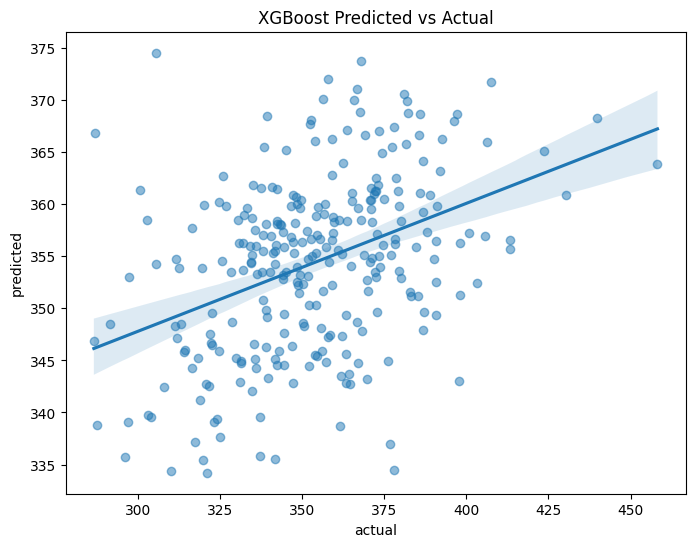

In [158]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_p, y_holdout_p)

R^2 Value of Holdout: 0.16
RMSE of Holdout: 25.09
Mean of Holdout: 353.52
This is 7.10% of the mean pheno data
0 405.602 357.41090647947954
1 307.984 344.82592503221645
2 339.283 352.3092319680085
3 370.721 363.0429363698767
4 337.116 332.43876611712665


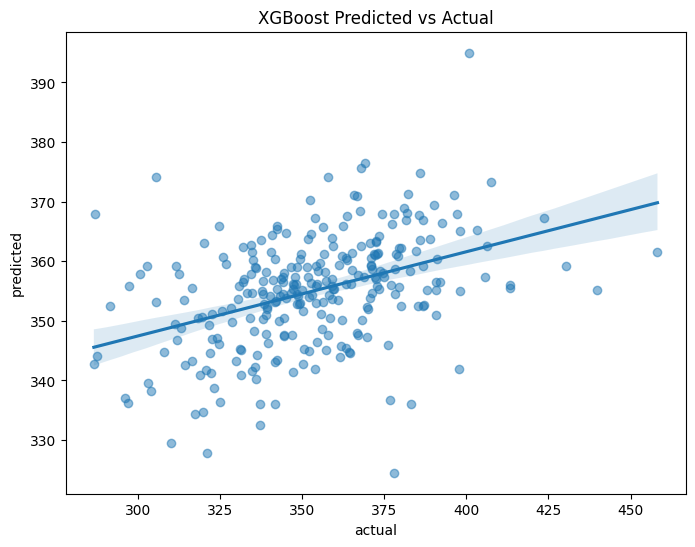

In [159]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_p, y_holdout_p)

R^2 Value of Holdout: 0.15
RMSE of Holdout: 25.30
Mean of Holdout: 353.52
This is 7.16% of the mean pheno data
0 405.602 357.94723126745583
1 307.984 345.2895895199609
2 339.283 365.51590376757053
3 370.721 361.6693877916486
4 337.116 332.19571924568737


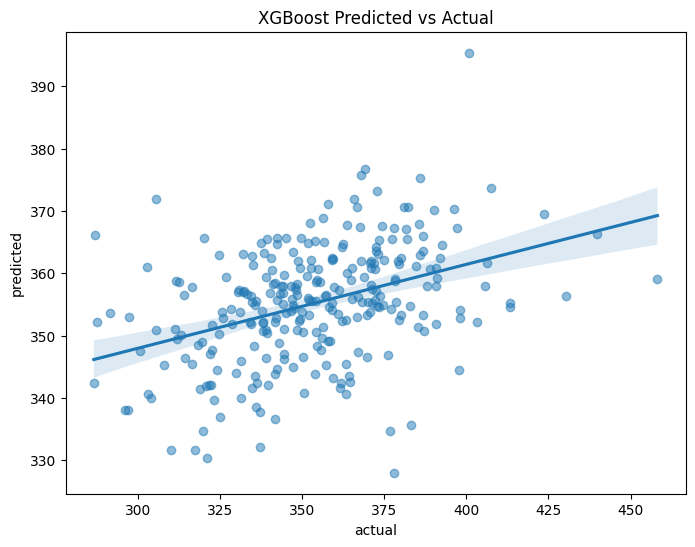

In [160]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_p, y_holdout_p)

In [69]:
explainer = shap.Explainer(best_xgbr_model)

In [197]:
explainer = shap.Explainer(best_rfr_model)

In [70]:
shap_values = explainer(X_dupe)

In [ ]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

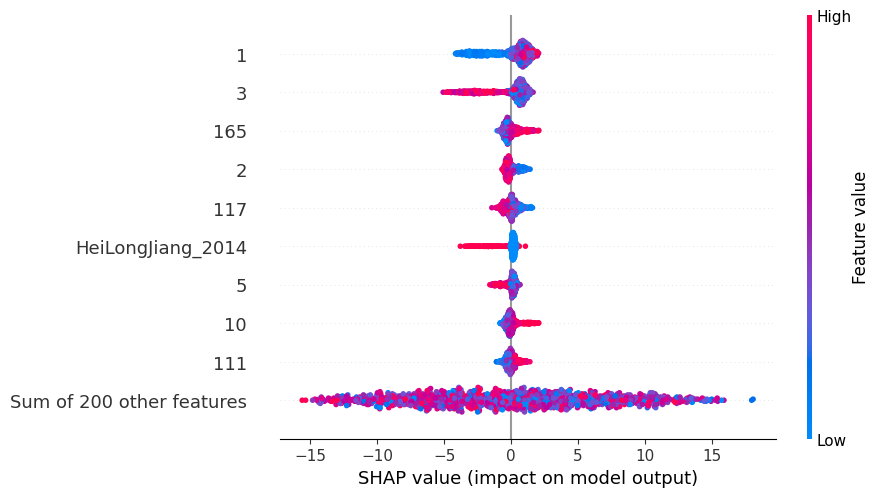

In [71]:
shap.plots.beeswarm(shap_values, show=False)

In [ ]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

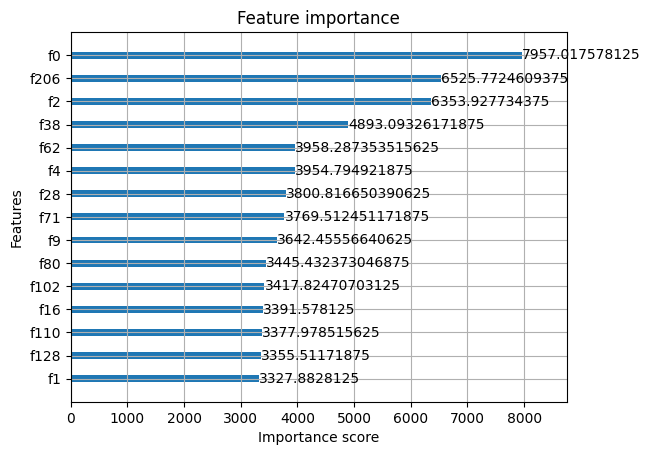

In [75]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

### Only location models 

In [40]:
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,196,197,198,199,200,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,0.023067,-0.009843,0.023802,-0.018460,0.009567,0,1,0,1,0


In [41]:
pca_loc.shape

(1094, 205)

In [42]:
y = pca_full_train_p.iloc[:, 509:]
y.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [43]:
y.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [81]:
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s233 to s744
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PRT     1094 non-null   float64
dtypes: float64(1)
memory usage: 49.4+ KB


In [82]:
X_train, X_test, y_train, y_test = train_test_split(pca_loc, y, test_size=0.1, random_state=42)

In [83]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,196,197,198,199,200,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s776,-0.017530,-0.032333,0.054655,-0.001789,-0.011154,-0.027620,-0.011509,-0.016235,-0.009594,-0.071494,...,0.009851,0.058966,-0.039506,-0.026859,0.001320,0,1,0,1,0
s1641,-0.013956,-0.061772,0.009886,0.057141,0.022730,0.025527,0.023882,0.009194,0.028309,-0.004532,...,0.020894,-0.033731,0.026299,0.062605,0.042861,1,0,0,1,0
s485,0.003651,-0.048856,-0.019152,-0.046943,-0.018778,0.014080,-0.014169,0.015491,0.003540,0.039615,...,-0.026916,0.032047,-0.020724,-0.053948,-0.047712,1,0,0,1,0
s299,-0.042114,0.028996,0.058033,-0.034057,-0.037556,-0.026473,-0.021424,-0.058986,-0.014831,-0.006582,...,0.023657,0.004839,-0.071907,-0.015341,0.044212,1,0,0,1,0
s805,0.022852,0.019387,0.015385,-0.048932,0.014338,-0.026326,-0.024687,-0.028552,0.040428,0.060398,...,0.011803,-0.013318,0.070755,0.022882,-0.008383,1,0,0,1,0


In [84]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [85]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.508862442878546), ('colsample_bytree', 0.9041806138781747), ('gamma', 1e-09), ('learning_rate', 0.01), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 3), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 1e-09), ('subsample', 0.7129989283432974)])


In [ ]:
#best_params =OrderedDict([('colsample_bylevel', 0.508862442878546), ('colsample_bytree', 0.9041806138781747), ('gamma', 1e-09), ('learning_rate', 0.01), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 3), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 1e-09), ('subsample', 0.7129989283432974)])

In [86]:
pca_loc = pca_loc.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.535137342434532
RMSE for dataset is:21.239794187179914& mean of this fold is 351.2612181818181
this is 6.046723375019977% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.094277889677781
RMSE for dataset is:21.227624758335008& mean of this fold is 355.7165454545454
this is 5.967567443681796% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.929860900825469
RMSE for dataset is:23.301083779668478& mean of this fold is 358.3097
this is 6.503056930825059% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.625350174012825
RMSE for dataset is:24.370435311106153& mean of this fold is 356.98939999999993
this is 6.826655164300721% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.378690361779841
RMSE for dataset is:23

In [44]:
#pickle.dump(best_xgbr_model, open("pca_200_best_model_onlyloc_xgbr_prt.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlyloc_xgbr_prt.pickle.dat", "rb"))

In [45]:
X_holdout_p = pca_full_holdout_p.iloc[:, :509]
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [46]:
y_holdout_p = pca_full_holdout_p.iloc[:, 509:]
y_holdout_p.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [47]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout_p = pca_loc_dupe.align(X_holdout_p, join='inner', axis=1)

In [48]:
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,196,197,198,199,200,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,-0.013503,-0.030513,0.016369,-0.084505,-0.087644,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,-0.084770,0.027059,0.009162,-0.038436,0.040243,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.008475,0.013980,0.028233,-0.021271,0.035880,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.005758,0.004417,0.039982,0.038942,0.003705,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.041198,0.004964,-0.008812,-0.044021,-0.003862,1,0,0,1,0


In [49]:
X_holdout_p = X_holdout_p.to_numpy()
y_holdout_p = y_holdout_p.to_numpy()

R^2 Value of Holdout: 0.15
RMSE of Holdout: 25.29
Mean of Holdout: 353.52
This is 7.15% of the mean pheno data
0 405.602 358.7126
1 307.984 337.79605
2 339.283 371.01227
3 370.721 361.728
4 337.116 335.44662


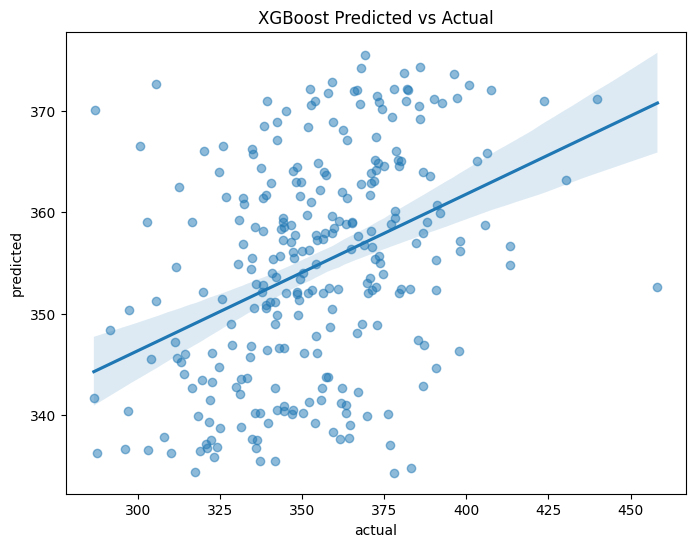

In [50]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_p, y_holdout_p)

In [94]:
explainer = shap.Explainer(best_xgbr_model)

In [95]:
shap_values = explainer(pca_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

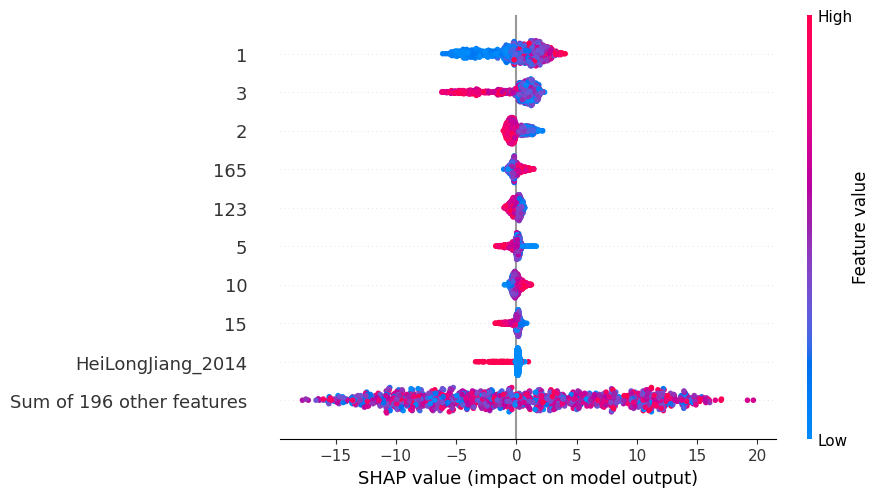

In [96]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

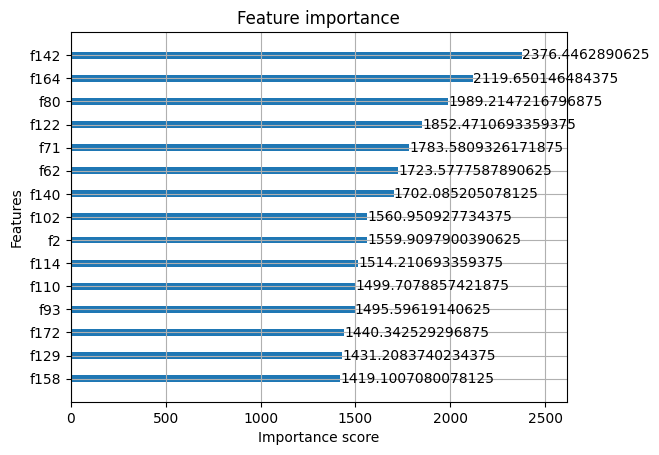

In [97]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [51]:
#### RF models

In [98]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 16), ('max_features', 'sqrt'), ('max_samples', 0.9844732143730294), ('min_samples_leaf', 5), ('min_samples_split', 20), ('n_estimators', 475)])


In [99]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [ ]:
best_rfr_model =  OrderedDict([('bootstrap', True), ('max_depth', 32), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])

In [100]:
best_rfr_model = eval_k_fold(best_rfreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.895743921379072
RMSE for dataset is:22.06738401872747& mean of this fold is 353.40469090909085
this is 6.244224988061645% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.46090614952635
RMSE for dataset is:20.937371107846523& mean of this fold is 354.75700000000006
this is 5.901890902179948% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.16411077388162
RMSE for dataset is:23.344926513444573& mean of this fold is 353.85983636363636
this is 6.597224130702041% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.925536622778767
RMSE for dataset is:20.34816831388024& mean of this fold is 355.04337272727264
this is 5.731178181858567% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.342617501566236
RMSE for datas

In [101]:
#pca_loc = pca_loc.to_numpy()
#y = y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -54.4462268510897
RMSE for dataset is:24.232348940655903& mean of this fold is 356.2818272727272
this is 6.801455220478165% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -73.17369832035227
RMSE for dataset is:24.432428814148277& mean of this fold is 357.056409090909
this is 6.84273638340647% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -44.607615963057185
RMSE for dataset is:24.76567171237269& mean of this fold is 353.6911909090909
this is 7.002060653169674% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -49.11915240316926
RMSE for dataset is:23.8998685955318& mean of this fold is 349.8546363636363
this is 6.831371121430689% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -63.91390907191534
RMSE for dataset is

In [51]:
#pickle.dump(best_rfr_model, open("pca_200_best_model_onlyloc_rfr_prt.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlyloc_rfr_prt.pickle.dat", "rb"))

In [52]:
#pickle.dump(best_svr_model, open("pca_200_best_model_onlyloc_svr_prt.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlyloc_svr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.16
RMSE of Holdout: 25.12
Mean of Holdout: 353.52
This is 7.11% of the mean pheno data
0 405.602 360.3495533961391
1 307.984 343.7103531157628
2 339.283 368.5483535192884
3 370.721 362.05927268581206
4 337.116 335.94839868170646


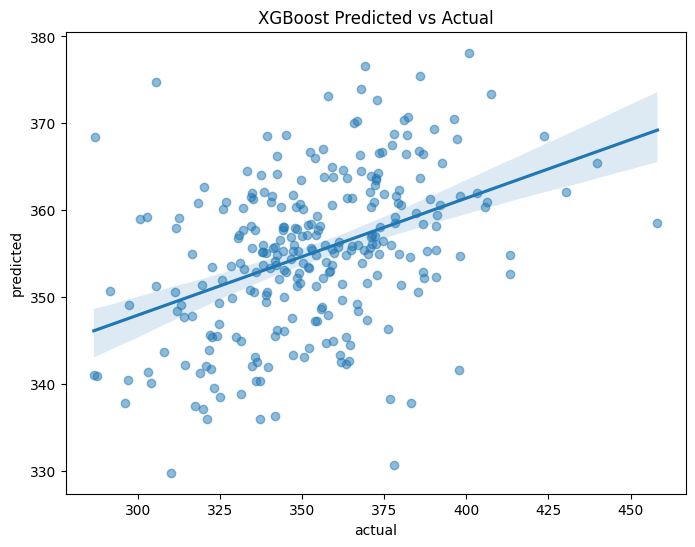

In [53]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_p, y_holdout_p)

R^2 Value of Holdout: 0.08
RMSE of Holdout: 26.32
Mean of Holdout: 353.52
This is 7.45% of the mean pheno data
0 405.602 354.7442330534304
1 307.984 343.59015190155793
2 339.283 355.8221184403463
3 370.721 356.9733684712809
4 337.116 353.1373142288301


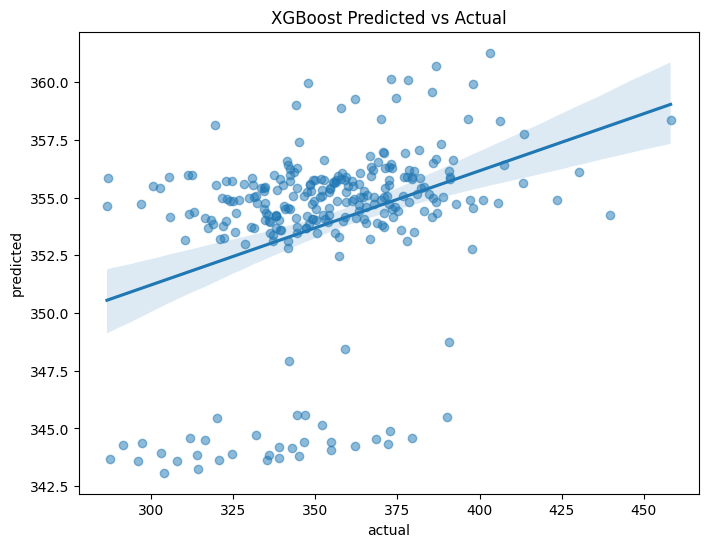

In [54]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_p, y_holdout_p)

### Only PCs

In [55]:
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.014839,0.013609,0.008501,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.014234,-0.019987,-0.006039,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.015354,0.037879,0.085191,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012463,0.065665,0.073180,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.016131,0.034417,-0.018315,0.023067,-0.009843,0.023802,-0.018460,0.009567,1,0


In [56]:
only_pca.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s233 to s744
Columns: 202 entries, 1 to landrace
dtypes: float64(200), int64(2)
memory usage: 1.7+ MB


In [57]:
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.014839,0.013609,0.008501,-0.029684,-0.021613,-0.062550,-0.013679,-0.004255,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.014234,-0.019987,-0.006039,-0.014262,0.020761,-0.018963,-0.029273,-0.007213,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.015354,0.037879,0.085191,0.096439,-0.033712,-0.023681,0.017747,0.021563,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,0.012463,0.065665,0.073180,0.012487,0.008690,0.030832,0.041246,-0.031854,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.016131,0.034417,-0.018315,0.023067,-0.009843,0.023802,-0.018460,0.009567,1,0


In [58]:
y = pca_full_train_p.iloc[:, 509:]
y.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [59]:
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s233 to s744
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PRT     1094 non-null   float64
dtypes: float64(1)
memory usage: 17.1+ KB


In [60]:
X_train, X_test, y_train, y_test = train_test_split(only_pca, y, test_size=0.1, random_state=42)

In [61]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s776,-0.017530,-0.032333,0.054655,-0.001789,-0.011154,-0.027620,-0.011509,-0.016235,-0.009594,-0.071494,...,0.020743,-0.014606,-0.010153,0.009851,0.058966,-0.039506,-0.026859,0.001320,1,0
s1641,-0.013956,-0.061772,0.009886,0.057141,0.022730,0.025527,0.023882,0.009194,0.028309,-0.004532,...,0.097943,0.008332,-0.007521,0.020894,-0.033731,0.026299,0.062605,0.042861,1,0
s485,0.003651,-0.048856,-0.019152,-0.046943,-0.018778,0.014080,-0.014169,0.015491,0.003540,0.039615,...,0.007583,-0.040474,-0.000741,-0.026916,0.032047,-0.020724,-0.053948,-0.047712,1,0
s299,-0.042114,0.028996,0.058033,-0.034057,-0.037556,-0.026473,-0.021424,-0.058986,-0.014831,-0.006582,...,0.029778,0.019804,-0.021627,0.023657,0.004839,-0.071907,-0.015341,0.044212,1,0
s805,0.022852,0.019387,0.015385,-0.048932,0.014338,-0.026326,-0.024687,-0.028552,0.040428,0.060398,...,0.034587,0.010832,-0.026672,0.011803,-0.013318,0.070755,0.022882,-0.008383,1,0


In [62]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [115]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.9458057343060261), ('colsample_bytree', 0.8788153326499153), ('gamma', 0.0013501684543623747), ('learning_rate', 0.06339045407156908), ('max_delta_step', 4), ('max_depth', 24), ('min_child_weight', 3), ('n_estimators', 83), ('reg_alpha', 3.17664282316827e-09), ('reg_lambda', 0.007538022480420767), ('subsample', 0.3679537111446328)])


In [ ]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.9458057343060261), ('colsample_bytree', 0.8788153326499153), ('gamma', 0.0013501684543623747), ('learning_rate', 0.06339045407156908), ('max_delta_step', 4), ('max_depth', 24), ('min_child_weight', 3), ('n_estimators', 83), ('reg_alpha', 3.17664282316827e-09), ('reg_lambda', 0.007538022480420767), ('subsample', 0.3679537111446328)])

In [116]:
only_pca = only_pca.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, only_pca, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.97990330071829
RMSE for dataset is:21.899408415789832& mean of this fold is 352.1223636363636
this is 6.219260881255849% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.953623132515188
RMSE for dataset is:22.59808566115215& mean of this fold is 357.0891727272727
this is 6.3284152494904875% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.687669367735516
RMSE for dataset is:22.089509432812488& mean of this fold is 358.6916
this is 6.158357049011599% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.655900404083841
RMSE for dataset is:21.286485249004716& mean of this fold is 356.8811181818181
this is 5.964587131269863% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.839444991690133
RMSE for dataset is:21.

In [63]:
#pickle.dump(best_xgbr_model, open("pca_200_best_model_onlypcs_xgbr_prt.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlypcs_xgbr_prt.pickle.dat", "rb"))

In [64]:
pca_full_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,61,6.83333,9.73333,109.567,1,0,0,1,0,405.602
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,78,3.74000,9.98000,59.000,0,0,1,1,0,307.984
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,30,6.86667,9.42667,77.000,0,1,0,1,0,339.283
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,42,8.03333,10.66000,100.000,0,1,0,1,0,370.721
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,47,8.00000,10.36670,59.400,1,0,0,1,0,337.116


In [65]:
X_holdout_p = pca_full_holdout_p.iloc[:, :509]
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [66]:
y_holdout_p = pca_full_holdout_p.iloc[:, 509:]
y_holdout_p.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [67]:
# Ensure both training and holdout datasets have the same columns
only_pca_dupe, X_holdout_p = only_pca_dupe.align(X_holdout_p, join='inner', axis=1)

In [68]:
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,-0.014849,-0.015947,-0.059806,-0.013503,-0.030513,0.016369,-0.084505,-0.087644,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,-0.022959,-0.019405,0.075055,-0.084770,0.027059,0.009162,-0.038436,0.040243,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,0.027785,-0.034408,-0.001514,-0.008475,0.013980,0.028233,-0.021271,0.035880,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,-0.049687,0.001613,0.006969,0.005758,0.004417,0.039982,0.038942,0.003705,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.026146,-0.023648,0.003912,0.041198,0.004964,-0.008812,-0.044021,-0.003862,1,0


In [69]:
X_holdout_p = X_holdout_p.to_numpy()
y_holdout_p = y_holdout_p.to_numpy()

R^2 Value of Holdout: 0.12
RMSE of Holdout: 25.70
Mean of Holdout: 353.52
This is 7.27% of the mean pheno data
0 405.602 353.61487
1 307.984 347.63016
2 339.283 364.96994
3 370.721 362.77377
4 337.116 344.99487


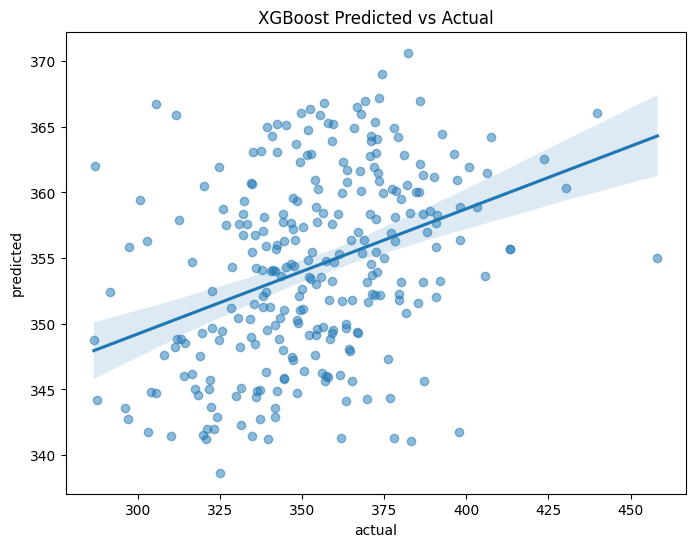

In [70]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_p, y_holdout_p)

In [ ]:
#### RF Models

In [126]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 37), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 5), ('min_samples_split', 20), ('n_estimators', 494)])


In [127]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 1.5), ('kernel', 'poly')])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 37), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 5), ('min_samples_split', 20), ('n_estimators', 494)])

In [128]:
best_rfr_model = eval_k_fold(best_rfreg, only_pca, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.862106520780692
RMSE for dataset is:20.360247012324606& mean of this fold is 354.5846454545454
this is 5.741999060964586% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.2592385306415235
RMSE for dataset is:23.563346404999837& mean of this fold is 352.4262818181818
this is 6.686035525907874% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.831704911405265
RMSE for dataset is:22.609883803324852& mean of this fold is 356.4841909090909
this is 6.342464653387878% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.525833591282066
RMSE for dataset is:25.382328199221956& mean of this fold is 353.28078181818165
this is 7.184746384615154% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.190129540295467
RMSE for dat

In [129]:
#only_pca = only_pca.to_numpy()
#y = y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, only_pca, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -658.287083998577
RMSE for dataset is:26.19265138985608& mean of this fold is 353.7599363636364
this is 7.404075107852847% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -179.89201855270576
RMSE for dataset is:20.36781983937809& mean of this fold is 352.6369999999999
this is 5.775860116600951% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -499.16231823877763
RMSE for dataset is:23.008408294343816& mean of this fold is 351.8750999999999
this is 6.538799788431697% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -404.16929981018217
RMSE for dataset is:22.830136493296195& mean of this fold is 355.4207636363637
this is 6.423411018455312% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -413.6177876683215
RMSE for datas

In [72]:
#pickle.dump(best_rfr_model, open("pca_200_best_model_onlypcs_rfr_prt.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlypcs_rfr_prt.pickle.dat", "rb"))

In [75]:
#pickle.dump(best_svr_model, open("pca_200_best_model_onlypcs_svr_prt.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_200_best_model_onlypcs_svr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.14
RMSE of Holdout: 25.39
Mean of Holdout: 353.52
This is 7.18% of the mean pheno data
0 405.602 359.3030958445856
1 307.984 344.0178674575415
2 339.283 366.91697048446264
3 370.721 361.52703647593484
4 337.116 334.9236279470962


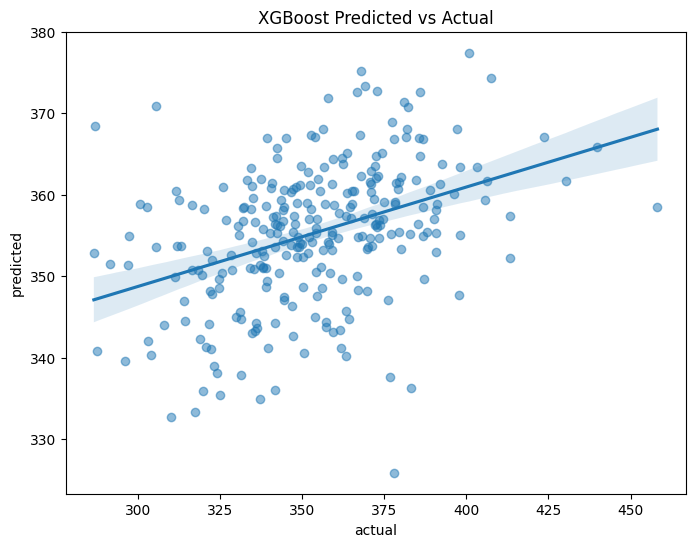

In [76]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_p, y_holdout_p)

R^2 Value of Holdout: 0.04
RMSE of Holdout: 26.91
Mean of Holdout: 353.52
This is 7.61% of the mean pheno data
0 405.602 354.11742336428176
1 307.984 352.86056133633895
2 339.283 353.97892237330836
3 370.721 355.37824711896155
4 337.116 352.280820161296


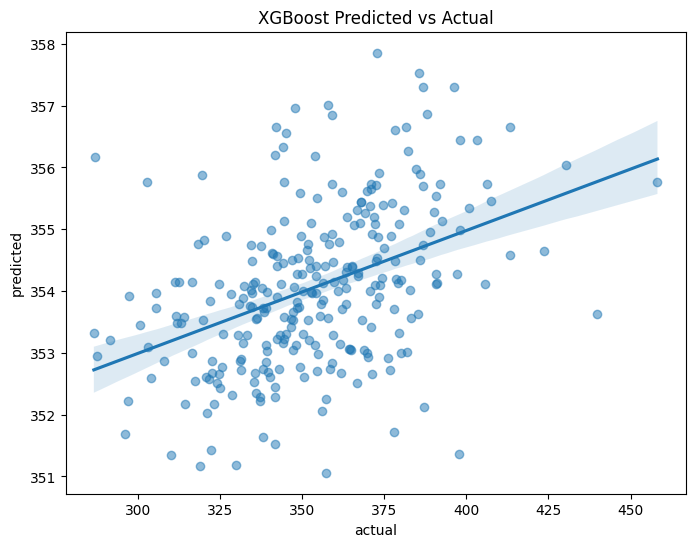

In [77]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_p, y_holdout_p)

# PC500 models

In [78]:
y = pca_full_train_p.iloc[:, 509:]
y.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [79]:
X = pca_full_train_p.iloc[:, 0:509]
X.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.013360,33,6.88000,9.02667,41.0000,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.022377,61,7.20000,9.20000,62.5667,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,-0.039258,81,6.86667,9.60000,100.8670,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.024071,77,8.00000,9.13333,98.3333,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.011595,38,4.82000,9.82000,42.0000,0,1,0,1,0


In [80]:
X_dupe = pca_full_train_p.iloc[:, 0:509]
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.013360,33,6.88000,9.02667,41.0000,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.022377,61,7.20000,9.20000,62.5667,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,-0.039258,81,6.86667,9.60000,100.8670,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.024071,77,8.00000,9.13333,98.3333,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.011595,38,4.82000,9.82000,42.0000,0,1,0,1,0


In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [82]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [141]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4643355659323092), ('colsample_bytree', 0.8686544399741403), ('gamma', 0.49999999999999994), ('learning_rate', 0.017386738514664452), ('max_delta_step', 11), ('max_depth', 18), ('min_child_weight', 4), ('n_estimators', 186), ('reg_alpha', 5.452363101494264e-06), ('reg_lambda', 0.09016712895361159), ('subsample', 0.6813930281367574)])


In [97]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4643355659323092), ('colsample_bytree', 0.8686544399741403), ('gamma', 0.49999999999999994), ('learning_rate', 0.017386738514664452), ('max_delta_step', 11), ('max_depth', 18), ('min_child_weight', 4), ('n_estimators', 186), ('reg_alpha', 5.452363101494264e-06), ('reg_lambda', 0.09016712895361159), ('subsample', 0.6813930281367574)])
best_params = {
    'colsample_bylevel': 0.16975074821232053,
    'colsample_bytree': 0.7700635638092945,
    'gamma': 0.49999999999999994,
    'learning_rate': 0.08281369575374707,
    'max_delta_step': 20,
    'max_depth': 4,
    'min_child_weight': 2,
    'n_estimators': 200,
    'reg_alpha': 1.3998058433748922e-09,
    'reg_lambda': 6.998838349296903,
    'subsample': 0.9094311201012985
}
best_xgbreg = xgb.XGBRegressor(**best_params)

In [154]:
#X = X.to_numpy()
#y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.9305086528882276
RMSE for dataset is:20.503635951766892& mean of this fold is 356.60167272727267
this is 5.749730727552694% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.975717085797093
RMSE for dataset is:23.06363204779631& mean of this fold is 356.3015090909091
this is 6.473066057632583% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.511027847564571
RMSE for dataset is:23.932990193968244& mean of this fold is 356.3411727272727
this is 6.716313473067414% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.62295509019921
RMSE for dataset is:22.354337554340766& mean of this fold is 350.2768272727272
this is 6.381905913786176% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.3282520471667802
RMSE for data

In [83]:
#pickle.dump(best_xgbr_model, open("pca_500_best_model_allfeats_xgbr_prt.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_allfeats_xgbr_prt.pickle.dat", "rb"))

In [84]:
X_holdout_p = pca_full_holdout_p.iloc[:, 0:509]
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [85]:
y_holdout_p = pca_full_holdout_p.iloc[:, 509:]
y_holdout_p.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [86]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout_p = X_dupe.align(X_holdout_p, join='inner', axis=1)

In [87]:
X_holdout_p = X_holdout_p.to_numpy()
y_holdout_p = y_holdout_p.to_numpy()

R^2 Value of Holdout: 0.17
RMSE of Holdout: 24.97
Mean of Holdout: 353.52
This is 7.06% of the mean pheno data
0 405.602 359.95792
1 307.984 337.9978
2 339.283 378.8849
3 370.721 363.18555
4 337.116 330.50772


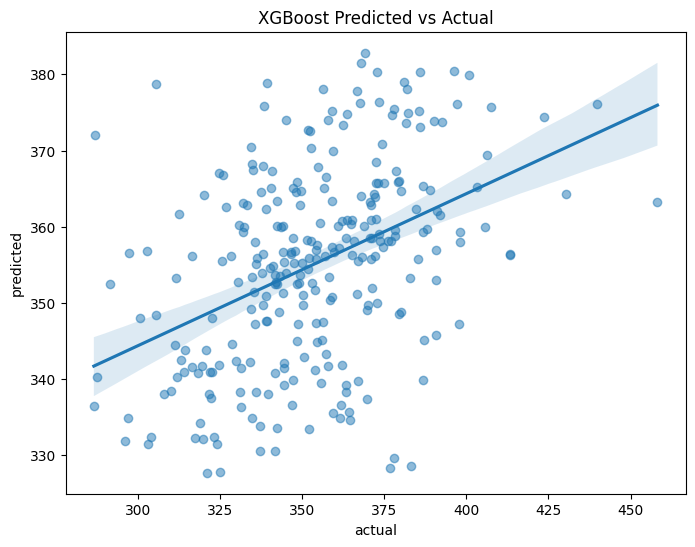

In [88]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_p, y_holdout_p)

In [157]:
explainer = shap.Explainer(best_xgbr_model)

In [158]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

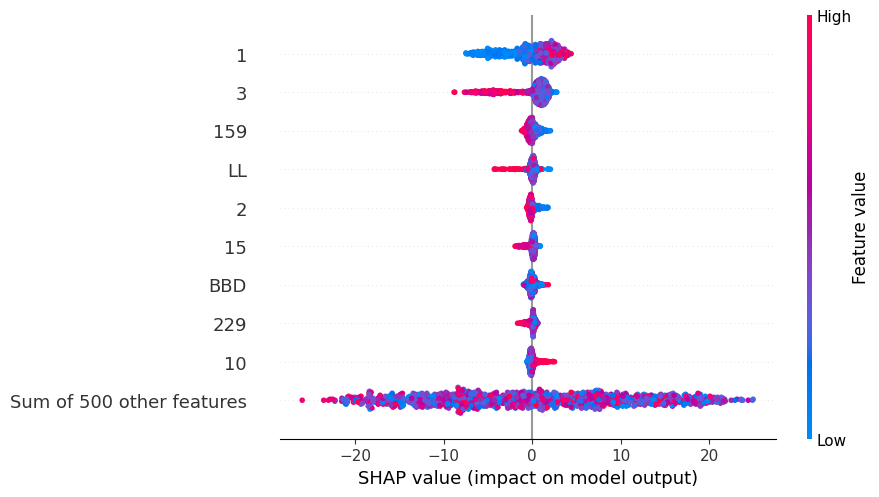

In [159]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

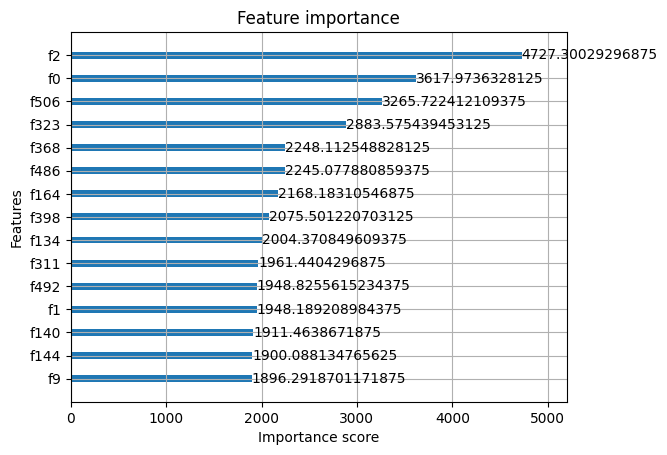

In [152]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [160]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.8859936093717724), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 256)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.8859936093717724), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 256)])
Selection deleted


In [165]:
#X = X.to_numpy()
#y = y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.985306581571847
RMSE for dataset is:19.530597928784836& mean of this fold is 356.6345454545454
this is 5.476361776420814% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.281291561582421
RMSE for dataset is:22.37265037608505& mean of this fold is 357.60443636363635
this is 6.256256383054216% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.742641996475744
RMSE for dataset is:24.874666846872163& mean of this fold is 359.95334545454546
this is 6.910525255838554% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.675027720177825
RMSE for dataset is:21.708879206802703& mean of this fold is 356.1406454545455
this is 6.095591582672476% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.436610938840468
RMSE for data

In [89]:
#pickle.dump(best_rfr_model, open("pca_500_best_model_allfeats_rfr_prt.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_allfeats_rfr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.15
RMSE of Holdout: 25.26
Mean of Holdout: 353.52
This is 7.15% of the mean pheno data
0 405.602 356.17010492897367
1 307.984 345.7473329586429
2 339.283 367.8311546077815
3 370.721 357.4723721962113
4 337.116 335.746562183167


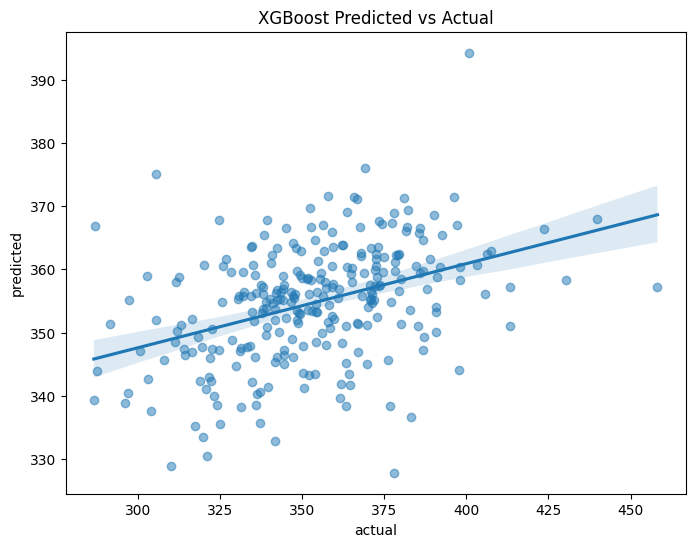

In [90]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_p, y_holdout_p)

In [91]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

NameError: name 'bayesian_svr_search' is not defined

In [170]:
best_svr_model = eval_k_fold(best_svreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.746451020884498
RMSE for dataset is:22.495910532508745& mean of this fold is 351.5674454545455
this is 6.398746762068236% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -22.851505260798383
RMSE for dataset is:22.31402145355412& mean of this fold is 354.8138818181817
this is 6.288936988375375% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -28.808559731257997
RMSE for dataset is:23.825906409695452& mean of this fold is 351.21580909090915
this is 6.783836545218932% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -15.334131903153384
RMSE for dataset is:21.552473604200983& mean of this fold is 356.93393636363635
this is 6.038224838963982% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -23.282965118937184
RMSE for

In [92]:
#pickle.dump(best_svr_model, open("pca_500_best_model_allfeats_svr_prt.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_allfeats_svr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.07
RMSE of Holdout: 26.39
Mean of Holdout: 353.52
This is 7.46% of the mean pheno data
0 405.602 354.2263012047813
1 307.984 349.29159702698666
2 339.283 354.1820455281129
3 370.721 357.0244779551201
4 337.116 351.2012398510258


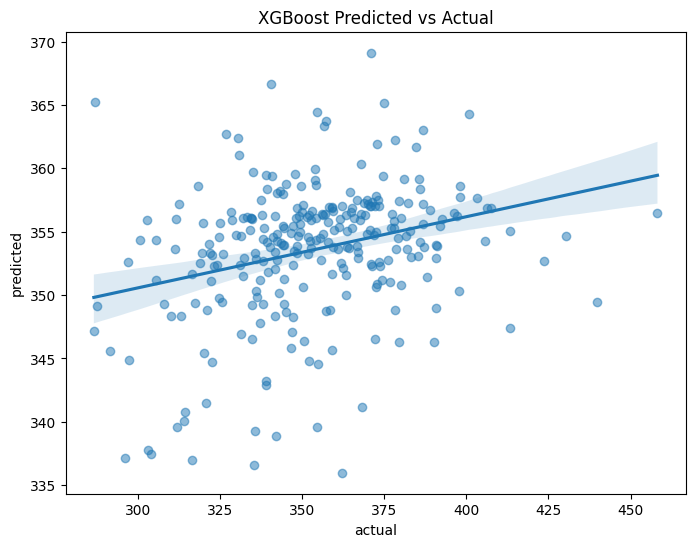

In [93]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_p, y_holdout_p)

In [32]:
explainer = shap.Explainer(best_rfr_model)

In [ ]:
shap_values = explainer(X_dupe)

In [ ]:
shap.plots.beeswarm(shap_values, show=False)

### Only location Models

In [94]:
pca_loc= X_dupe.drop(['BBD', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,496,497,498,499,500,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.002424,-0.021051,-0.034366,-0.068256,0.013360,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.032258,-0.006708,0.009431,-0.011996,0.022377,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,-0.023095,0.032951,0.037934,-0.014143,-0.039258,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.001107,0.003202,-0.018890,-0.008451,-0.024071,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.005132,-0.008824,-0.025641,-0.025157,-0.011595,0,1,0,1,0


In [95]:
pca_loc_dupe = X_dupe.drop(['BBD', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,496,497,498,499,500,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,-0.002424,-0.021051,-0.034366,-0.068256,0.013360,0,1,0,1,0
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,-0.032258,-0.006708,0.009431,-0.011996,0.022377,1,0,0,1,0
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,-0.023095,0.032951,0.037934,-0.014143,-0.039258,1,0,0,1,0
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.001107,0.003202,-0.018890,-0.008451,-0.024071,1,0,0,1,0
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.005132,-0.008824,-0.025641,-0.025157,-0.011595,0,1,0,1,0


In [96]:
y = pca_full_train_p.iloc[:, 509:]
y.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [97]:
X_train, X_test, y_train, y_test = train_test_split(pca_loc, y, test_size=0.1, random_state=42)

In [98]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [181]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 1.0), ('gamma', 0.49999999999999994), ('learning_rate', 0.07499560838272876), ('max_delta_step', 0), ('max_depth', 0), ('min_child_weight', 0), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 1000.0), ('subsample', 1.0)])


In [28]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 1.0), ('gamma', 0.49999999999999994), ('learning_rate', 0.07499560838272876), ('max_delta_step', 0), ('max_depth', 0), ('min_child_weight', 0), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 1000.0), ('subsample', 1.0)])
best_params = {
    'colsample_bylevel': 0.32513276360584337,
    'colsample_bytree': 0.7441631972964099,
    'gamma': 1.0018239220770246e-05,
    'learning_rate': 0.03685249314342051,
    'max_delta_step': 15,
    'max_depth': 31,
    'min_child_weight': 10,
    'n_estimators': 200,
    'reg_alpha': 0.05639729435110135,
    'reg_lambda': 1.4938425796098453,
    'subsample': 0.8414111163579864
}
best_xgbreg = xgb.XGBRegressor(**best_params)

In [ ]:
OrderedDict([('colsample_bylevel', 0.32513276360584337), ('colsample_bytree', 0.7441631972964099), ('gamma', 1.0018239220770246e-05), ('learning_rate', 0.03685249314342051), ('max_delta_step', 15), ('max_depth', 31), ('min_child_weight', 10), ('n_estimators', 200), ('reg_alpha', 0.05639729435110135), ('reg_lambda', 1.4938425796098453), ('subsample', 0.8414111163579864)])

In [192]:
#pca_loc = pca_loc.to_numpy()
#y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.880277352724373
RMSE for dataset is:22.037476859117938& mean of this fold is 353.9329181818182
this is 6.226455841498503% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.332069763428278
RMSE for dataset is:23.79810554536373& mean of this fold is 353.60907272727263
this is 6.730060787698863% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.632231416032496
RMSE for dataset is:22.222138117546987& mean of this fold is 356.7586272727272
this is 6.228899995334683% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.8940150850423283
RMSE for dataset is:24.879138406638752& mean of this fold is 353.13105454545456
this is 7.045298929787649% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.367367969589106
RMSE for dat

In [99]:
#pickle.dump(best_xgbr_model, open("pca_500_best_model_onlyloc_xgbr_prt.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlyloc_xgbr_prt.pickle.dat", "rb"))

In [100]:
pca_full_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,61,6.83333,9.73333,109.567,1,0,0,1,0,405.602
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,78,3.74000,9.98000,59.000,0,0,1,1,0,307.984
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,30,6.86667,9.42667,77.000,0,1,0,1,0,339.283
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,42,8.03333,10.66000,100.000,0,1,0,1,0,370.721
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,47,8.00000,10.36670,59.400,1,0,0,1,0,337.116


In [101]:
X_holdout_p = pca_full_holdout_p.iloc[:, :509]
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.025688,61,6.83333,9.73333,109.567,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.039107,78,3.74000,9.98000,59.000,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.020326,30,6.86667,9.42667,77.000,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.017548,42,8.03333,10.66000,100.000,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.035709,47,8.00000,10.36670,59.400,1,0,0,1,0


In [102]:
y_holdout_p = pca_full_holdout_p.iloc[:, 509:]
y_holdout_p.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [103]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout_p = pca_loc_dupe.align(X_holdout_p, join='inner', axis=1)

In [104]:
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,496,497,498,499,500,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.048746,0.015470,-0.002135,0.020298,0.025688,1,0,0,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,-0.039820,0.016543,-0.002721,-0.004126,0.039107,0,0,1,1,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.074818,-0.065688,-0.036566,-0.007294,-0.020326,0,1,0,1,0
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,-0.014332,0.023294,-0.001542,-0.000867,0.017548,0,1,0,1,0
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,-0.019979,0.051863,-0.022576,-0.029524,0.035709,1,0,0,1,0


In [105]:
X_holdout_p = X_holdout_p.to_numpy()
y_holdout_p = y_holdout_p.to_numpy()

R^2 Value of Holdout: 0.14
RMSE of Holdout: 25.50
Mean of Holdout: 353.52
This is 7.21% of the mean pheno data
0 405.602 358.43286
1 307.984 338.5697
2 339.283 372.80008
3 370.721 364.18134
4 337.116 331.45126


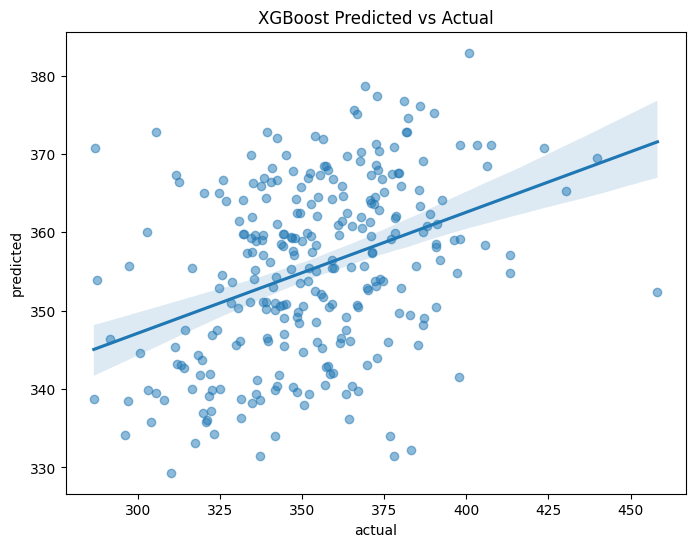

In [106]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_p, y_holdout_p)

In [195]:
explainer = shap.Explainer(best_xgbr_model)

In [196]:
shap_values = explainer(pca_loc_dupe)

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was 6819.313477, while the model output was 352.676910. If this difference is acceptable you can set check_additivity=False to disable this check.

In [ ]:
shap.plots.beeswarm(shap_values, show=False)

In [42]:
#### RF Models

In [197]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 17), ('max_features', 'sqrt'), ('max_samples', 0.7852866668383001), ('min_samples_leaf', 5), ('min_samples_split', 11), ('n_estimators', 495)])


In [198]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 17), ('max_features', 'sqrt'), ('max_samples', 0.7852866668383001), ('min_samples_leaf', 5), ('min_samples_split', 11), ('n_estimators', 495)])

In [199]:
best_rfr_model = eval_k_fold(best_rfreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.881238540216748
RMSE for dataset is:20.866371391937857& mean of this fold is 354.16959090909074
this is 5.891632688841967% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.698645434483127
RMSE for dataset is:22.29641965910827& mean of this fold is 354.76719090909086
this is 6.284803169643083% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.567020324413004
RMSE for dataset is:22.234032039187593& mean of this fold is 349.71509090909086
this is 6.3577559611138925% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.579815096515324
RMSE for dataset is:22.485587662149598& mean of this fold is 356.28980909090905
this is 6.311038679305109% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.260966594817048
RMSE for d

In [200]:
#pca_loc = pca_loc.to_numpy()
#y = y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -62.20417602797435
RMSE for dataset is:22.246878253692806& mean of this fold is 354.57939090909093
this is 6.274159983369305% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -43.67993858190825
RMSE for dataset is:24.61373090956492& mean of this fold is 356.1727727272728
this is 6.910615519848299% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -59.67886818657626
RMSE for dataset is:25.980892209816783& mean of this fold is 356.46569090909094
this is 7.288469233478816% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -69.21787827475295
RMSE for dataset is:25.314514348788194& mean of this fold is 353.93613636363636
this is 7.1522830669033155% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -58.91413139485919
RMSE for da

In [107]:
#pickle.dump(best_rfr_model, open("pca_500_best_model_onlyloc_rfr_prt.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlyloc_rfr_prt.pickle.dat", "rb"))

In [108]:
#pickle.dump(best_svr_model, open("pca_500_best_model_onlyloc_svr_prt.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlyloc_svr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.12
RMSE of Holdout: 25.67
Mean of Holdout: 353.52
This is 7.26% of the mean pheno data
0 405.602 356.0083949519532
1 307.984 343.83158809706396
2 339.283 370.3982673241542
3 370.721 359.39624800585
4 337.116 336.6239933681705


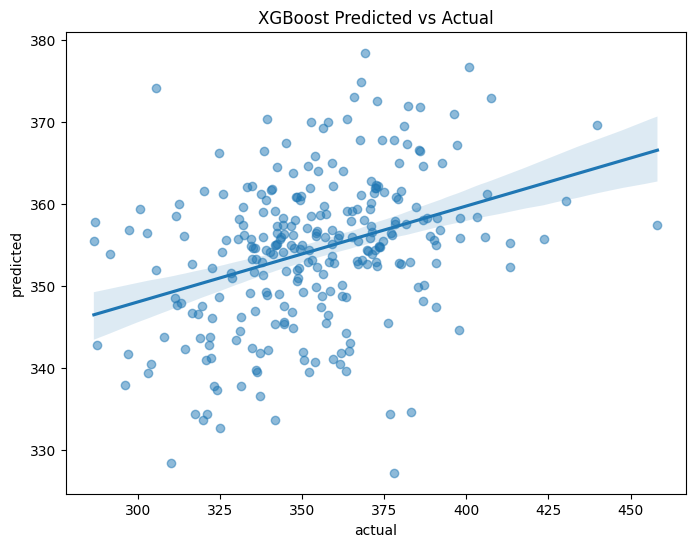

In [109]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_p, y_holdout_p)

R^2 Value of Holdout: 0.08
RMSE of Holdout: 26.28
Mean of Holdout: 353.52
This is 7.44% of the mean pheno data
0 405.602 354.934699645754
1 307.984 344.0679434839089
2 339.283 355.7502415263106
3 370.721 356.6932202190009
4 337.116 354.3760940156379


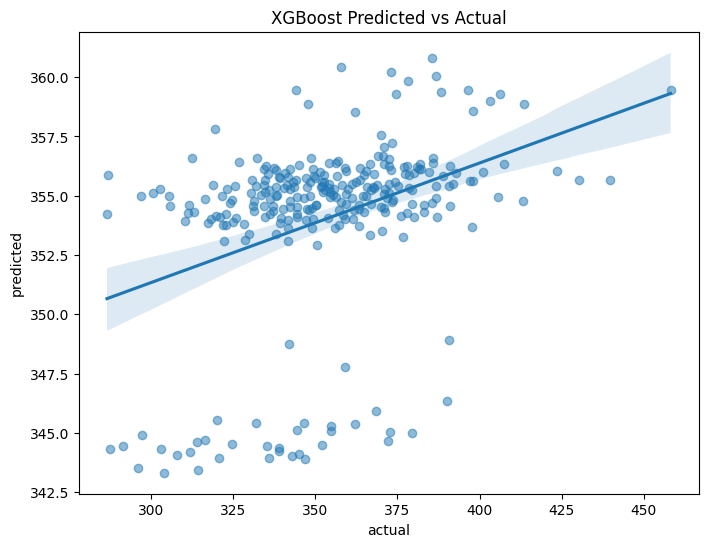

In [110]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_p, y_holdout_p)

In [47]:
### Only PCs models

In [111]:
y = pca_full_train_p.iloc[:, 509:]
y.head()

,PRT
Line,
s233,328.773
s582,354.750
s472,332.734
s531,327.574
s848,376.204


In [112]:
pca_only =  pca_full_train_p.iloc[:, :500]
pca_only.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.081175,-0.008593,-0.021243,-0.019327,0.034828,-0.002424,-0.021051,-0.034366,-0.068256,0.013360
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.009136,-0.012727,-0.008576,0.011897,0.014173,-0.032258,-0.006708,0.009431,-0.011996,0.022377
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.046973,-0.011274,0.001273,-0.005819,0.034749,-0.023095,0.032951,0.037934,-0.014143,-0.039258
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.028776,0.025225,0.005238,-0.069780,-0.047269,-0.001107,0.003202,-0.018890,-0.008451,-0.024071
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.015445,0.019998,0.012256,0.001475,0.020746,-0.005132,-0.008824,-0.025641,-0.025157,-0.011595


In [113]:
pca_only_dupe =  pca_full_train_p.iloc[:, :500]
pca_only_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s233,0.001396,0.042770,-0.017712,-0.025535,0.086924,0.025324,-0.018883,-0.034880,-0.009066,-0.037799,...,0.081175,-0.008593,-0.021243,-0.019327,0.034828,-0.002424,-0.021051,-0.034366,-0.068256,0.013360
s582,-0.009126,-0.078569,0.016538,0.034037,-0.007446,0.024293,-0.023130,-0.005310,-0.005336,-0.011027,...,0.009136,-0.012727,-0.008576,0.011897,0.014173,-0.032258,-0.006708,0.009431,-0.011996,0.022377
s472,-0.007037,-0.032036,-0.023367,-0.038338,-0.017022,0.008173,-0.017272,-0.023033,0.002166,-0.010469,...,0.046973,-0.011274,0.001273,-0.005819,0.034749,-0.023095,0.032951,0.037934,-0.014143,-0.039258
s531,0.029820,0.006133,-0.021916,-0.019249,0.017618,0.000146,0.019469,0.005669,-0.004200,-0.000751,...,-0.028776,0.025225,0.005238,-0.069780,-0.047269,-0.001107,0.003202,-0.018890,-0.008451,-0.024071
s848,0.003401,-0.058498,0.001741,0.018172,0.035085,-0.037263,-0.083770,0.052072,0.057998,0.008686,...,-0.015445,0.019998,0.012256,0.001475,0.020746,-0.005132,-0.008824,-0.025641,-0.025157,-0.011595


In [210]:
X_train, X_test, y_train, y_test = train_test_split(pca_only, y, test_size=0.1, random_state=42)

In [211]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s776,-0.017530,-0.032333,0.054655,-0.001789,-0.011154,-0.027620,-0.011509,-0.016235,-0.009594,-0.071494,...,-0.058869,-0.015199,-0.002712,-0.014234,-0.005763,0.008247,0.010649,0.006449,0.026676,0.011352
s1641,-0.013956,-0.061772,0.009886,0.057141,0.022730,0.025527,0.023882,0.009194,0.028309,-0.004532,...,0.008034,-0.011921,-0.021898,-0.026552,0.030471,-0.008453,-0.028216,-0.030223,0.019558,0.035069
s485,0.003651,-0.048856,-0.019152,-0.046943,-0.018778,0.014080,-0.014169,0.015491,0.003540,0.039615,...,-0.000752,-0.027158,0.009457,0.010752,0.007907,-0.025390,0.017692,0.027867,-0.020959,0.046960
s299,-0.042114,0.028996,0.058033,-0.034057,-0.037556,-0.026473,-0.021424,-0.058986,-0.014831,-0.006582,...,-0.017421,0.043922,-0.020249,0.051943,0.016473,0.016768,-0.041390,0.014704,-0.009229,0.003730
s805,0.022852,0.019387,0.015385,-0.048932,0.014338,-0.026326,-0.024687,-0.028552,0.040428,0.060398,...,-0.008448,-0.014036,0.003317,-0.024423,-0.004513,0.029719,-0.010512,0.005278,-0.022464,-0.000065


In [212]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [213]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.7696097307315397), ('colsample_bytree', 0.4449691428461367), ('gamma', 0.00539877553797825), ('learning_rate', 0.3548437189740906), ('max_delta_step', 1), ('max_depth', 5), ('min_child_weight', 0), ('n_estimators', 85), ('reg_alpha', 0.00027774611110576634), ('reg_lambda', 1.5426368390417648e-06), ('subsample', 0.7537780636024077)])


In [ ]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.7696097307315397), ('colsample_bytree', 0.4449691428461367), ('gamma', 0.00539877553797825), ('learning_rate', 0.3548437189740906), ('max_delta_step', 1), ('max_depth', 5), ('min_child_weight', 0), ('n_estimators', 85), ('reg_alpha', 0.00027774611110576634), ('reg_lambda', 1.5426368390417648e-06), ('subsample', 0.7537780636024077)])

In [214]:
pca_only = pca_only.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, pca_only, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.430731713164903
RMSE for dataset is:23.951318951210098& mean of this fold is 356.6265
this is 6.716079413955524% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.7458328030669374
RMSE for dataset is:21.996723086925176& mean of this fold is 353.33315454545453
this is 6.225490816230609% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.748164065038118
RMSE for dataset is:20.805021028597203& mean of this fold is 352.6377727272727
this is 5.899827709236254% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.8794994743240014
RMSE for dataset is:24.383243513818105& mean of this fold is 359.861909090909
this is 6.775722269527104% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.96418661333861
RMSE for dataset is:21

In [114]:
#pickle.dump(best_xgbr_model, open("pca_500_best_model_onlypcs_xgbr_prt.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlypcs_xgbr_prt.pickle.dat", "rb"))

In [115]:
pca_full_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,61,6.83333,9.73333,109.567,1,0,0,1,0,405.602
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,78,3.74000,9.98000,59.000,0,0,1,1,0,307.984
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,30,6.86667,9.42667,77.000,0,1,0,1,0,339.283
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,42,8.03333,10.66000,100.000,0,1,0,1,0,370.721
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,47,8.00000,10.36670,59.400,1,0,0,1,0,337.116


In [116]:
X_holdout_p = pca_full_holdout_p.iloc[:, :5-9]
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,497,498,499,500,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.015470,-0.002135,0.020298,0.025688,61,6.83333,9.73333,109.567,1,0
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.016543,-0.002721,-0.004126,0.039107,78,3.74000,9.98000,59.000,0,0
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,-0.065688,-0.036566,-0.007294,-0.020326,30,6.86667,9.42667,77.000,0,1
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.023294,-0.001542,-0.000867,0.017548,42,8.03333,10.66000,100.000,0,1
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,0.051863,-0.022576,-0.029524,0.035709,47,8.00000,10.36670,59.400,1,0


In [117]:
y_holdout_p = pca_full_holdout_p.iloc[:, 509:]
y_holdout_p.head()

,PRT
Line,
s349,405.602
s723,307.984
s486,339.283
s426,370.721
s1576,337.116


In [118]:
# Ensure both training and holdout datasets have the same columns
pca_only_dupe, X_holdout_p = pca_only_dupe.align(X_holdout_p, join='inner', axis=1)

In [119]:
X_holdout_p.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s349,0.070399,0.038079,0.010900,0.015834,0.000438,0.009156,-0.015386,0.007256,0.006857,0.017542,...,0.018412,-0.037212,-0.014257,-0.027750,0.003648,0.048746,0.015470,-0.002135,0.020298,0.025688
s723,-0.024427,0.030487,-0.042931,0.030074,0.049175,-0.045681,-0.001480,-0.023506,-0.002754,-0.002551,...,0.046258,-0.070911,-0.031386,0.039016,-0.095890,-0.039820,0.016543,-0.002721,-0.004126,0.039107
s486,0.079884,0.019144,0.004679,-0.017871,-0.007468,-0.004190,-0.004124,-0.070220,0.003511,0.043828,...,0.088572,-0.015038,-0.045907,-0.018171,-0.013592,-0.074818,-0.065688,-0.036566,-0.007294,-0.020326
s426,0.011766,-0.047846,-0.018462,0.009778,0.001366,-0.015826,-0.039523,0.022136,-0.021279,0.034316,...,0.010871,0.091688,0.017820,-0.033908,-0.037262,-0.014332,0.023294,-0.001542,-0.000867,0.017548
s1576,-0.029052,0.001658,0.085615,-0.032479,-0.020324,0.019140,0.025771,0.017970,0.030279,0.021987,...,-0.005529,0.019826,-0.065168,-0.027400,0.020150,-0.019979,0.051863,-0.022576,-0.029524,0.035709


In [120]:
X_holdout_p = X_holdout_p.to_numpy()
y_holdout_p = y_holdout_p.to_numpy()

R^2 Value of Holdout: 0.12
RMSE of Holdout: 25.77
Mean of Holdout: 353.52
This is 7.29% of the mean pheno data
0 405.602 358.46854
1 307.984 337.71426
2 339.283 375.0177
3 370.721 364.764
4 337.116 330.30554


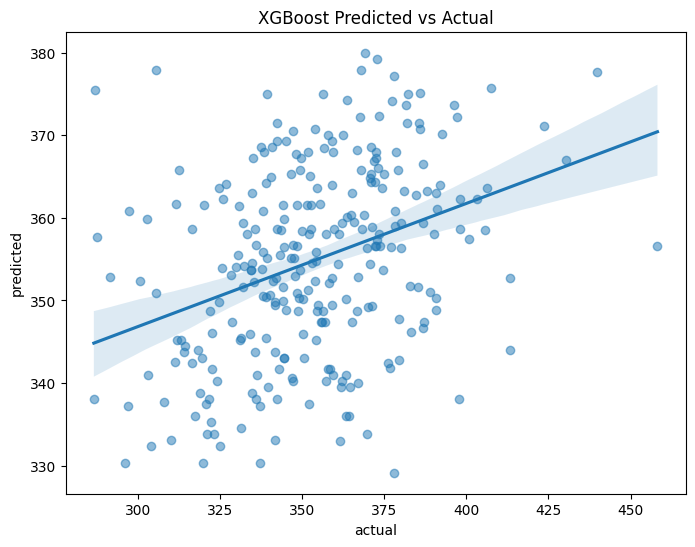

In [121]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_p, y_holdout_p)

In [224]:
explainer = shap.Explainer(best_xgbr_model)

In [225]:
shap_values = explainer(pca_only_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

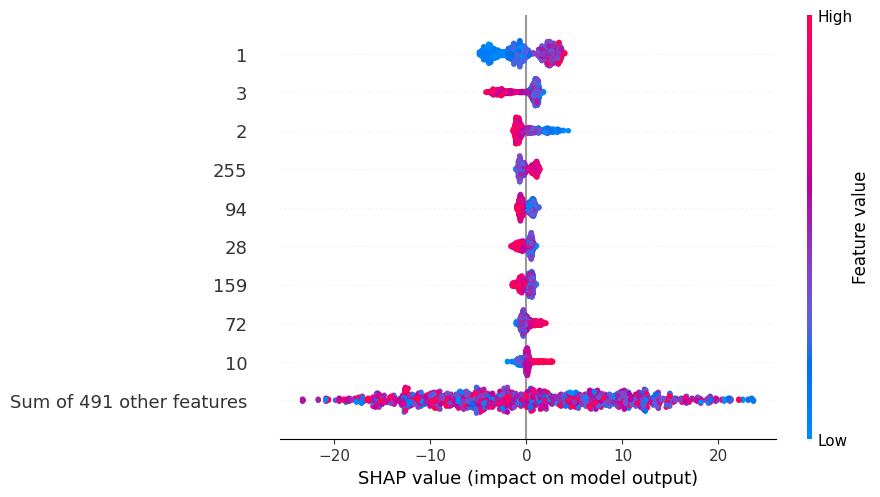

In [226]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

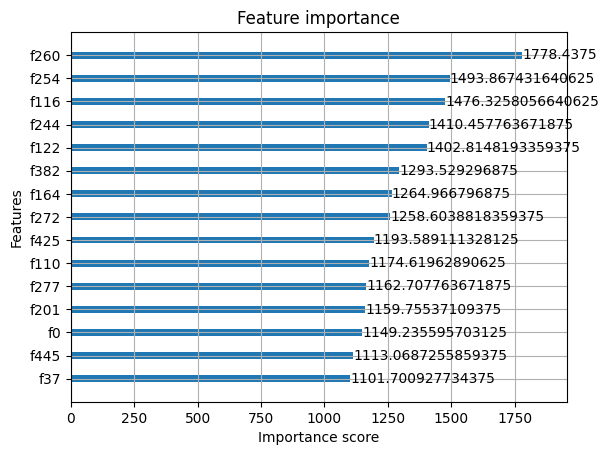

In [227]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

#### RF Models

In [228]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 49), ('max_features', 'sqrt'), ('max_samples', 0.9590893503813822), ('min_samples_leaf', 7), ('min_samples_split', 3), ('n_estimators', 218)])


In [229]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 0.5), ('kernel', 'rbf')])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 49), ('max_features', 'sqrt'), ('max_samples', 0.9590893503813822), ('min_samples_leaf', 7), ('min_samples_split', 3), ('n_estimators', 218)])

In [230]:
best_rfr_model = eval_k_fold(best_rfreg, pca_only, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.067786279767898
RMSE for dataset is:25.59013895653782& mean of this fold is 357.5044
this is 7.157992728631542% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.951408523184401
RMSE for dataset is:21.750855830069373& mean of this fold is 352.81918181818185
this is 6.164873383011877% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.654925736813618
RMSE for dataset is:18.983822191661258& mean of this fold is 358.1012181818182
this is 5.301244795549014% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.116207891277443
RMSE for dataset is:24.675370331296207& mean of this fold is 351.80776363636363
this is 7.013878851406254% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.297662962958604
RMSE for dataset is:2

In [235]:
#pca_only = pca_only.to_numpy()
#y = y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, pca_only, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -475.6777922502911
RMSE for dataset is:24.218759188553985& mean of this fold is 356.0249272727272
this is 6.802545926791691% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -276.31079878626747
RMSE for dataset is:24.16714955902044& mean of this fold is 355.62425454545445
this is 6.795697776550698% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -336.14307733784045
RMSE for dataset is:23.64635921068855& mean of this fold is 354.7694727272727
this is 6.665274503160696% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -470.6643530766698
RMSE for dataset is:24.524241274961188& mean of this fold is 360.0077636363636
this is 6.812142334722708% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -462.0863841530423
RMSE for data

In [122]:
#pickle.dump(best_rfr_model, open("pca_500_best_model_onlypcs_rfr_prt.pickle.dat", "wb"))
best_rfr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlypcs_rfr_prt.pickle.dat", "rb"))

In [123]:
#pickle.dump(best_svr_model, open("pca_500_best_model_onlypcs_svr_prt.pickle.dat", "wb"))
best_svr_model = pickle.load(open("../pickle_bestmodels/pca_500_best_model_onlypcs_svr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.13
RMSE of Holdout: 25.58
Mean of Holdout: 353.52
This is 7.24% of the mean pheno data
0 405.602 358.7182297597448
1 307.984 341.43780658743185
2 339.283 370.2936722158575
3 370.721 361.6961563617083
4 337.116 337.2964058331138


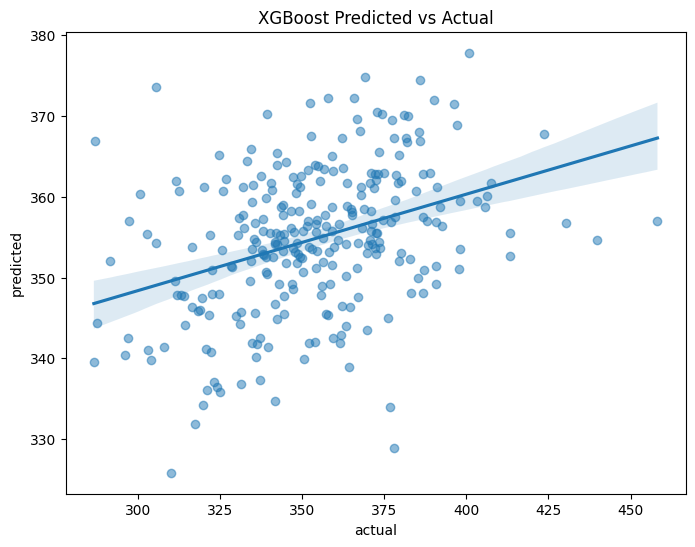

In [124]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_p, y_holdout_p)

R^2 Value of Holdout: 0.03
RMSE of Holdout: 27.01
Mean of Holdout: 353.52
This is 7.64% of the mean pheno data
0 405.602 355.6451833637789
1 307.984 354.25854118743763
2 339.283 355.31406564001304
3 370.721 356.6570193870951
4 337.116 353.91777320780085


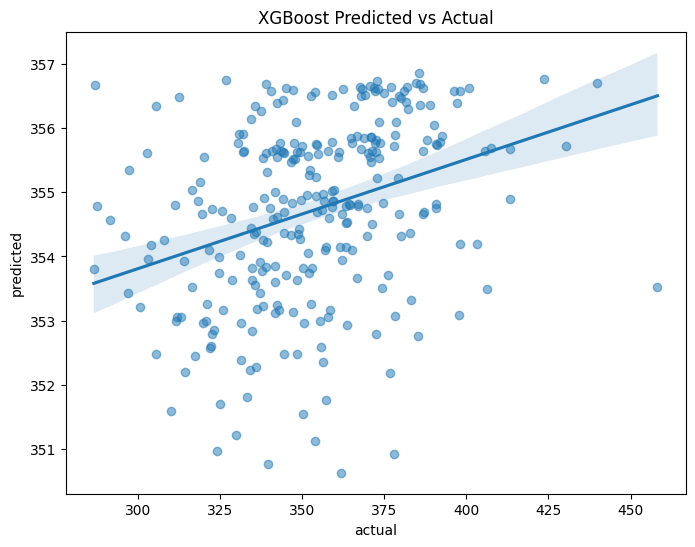

In [125]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_p, y_holdout_p)